# Рекомендательная система для онлайн-кинотеатра



# Датасет
- `users_en.csv` - профили пользователей (возраст, доход, пол, дети)
- `items_en.csv` - метаданные фильмов (жанры, описание, актёры, режиссёры)
- `interactions.csv` - история просмотров/взаимодействий (user_id, item_id, last_watch_dt, total_dur, content_type)

Ссылка: https://ods.ai/competitions/competition-recsys-21/data

# Установка библиотек

In [ ]:
!pip install implicit

In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import implicit
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import re
from sentence_transformers import SentenceTransformer
from collections import defaultdict

# Загрузка данных и первичный анализ

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
user_col = 'user_id'
item_col = 'item_id'
time_col = 'last_watch_dt'
K = 10   # длина списка рекомендаций

user_df  = pd.read_csv('/content/drive/MyDrive/КР26/data_en/users.csv')
item_df  = pd.read_csv('/content/drive/MyDrive/КР26/data_en/items.csv')
inter_df = pd.read_csv('/content/drive/MyDrive/КР26/data_en/interactions.csv')

print('Users:', user_df.shape,'| Столбцы:', user_df.columns.tolist())
print('Items:', item_df.shape,'| Столбцы:', item_df.columns.tolist())
print('Interactions:', inter_df.shape, '| Столбцы:', inter_df.columns.tolist())

Users: (840197, 5) | Столбцы: ['user_id', 'age', 'income', 'sex', 'kids_flg']
Items: (15963, 14) | Столбцы: ['item_id', 'content_type', 'title', 'title_orig', 'release_year', 'genres', 'countries', 'for_kids', 'age_rating', 'studios', 'directors', 'actors', 'description', 'keywords']
Interactions: (5476251, 5) | Столбцы: ['user_id', 'item_id', 'last_watch_dt', 'total_dur', 'watched_pct']


In [ ]:
print("USERS\n")
display(user_df.head(3))
print(f"Shape: {user_df.shape}")
print(user_df.dtypes)
print(f"\nПропуски:\n{user_df.isnull().sum()}")

USERS



,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0


Shape: (840197, 5)
user_id      int64
age         object
income      object
sex         object
kids_flg     int64
dtype: object

Пропуски:
user_id         0
age         14095
income      14776
sex         13831
kids_flg        0
dtype: int64


In [ ]:
print("ITEMS\n")
display(item_df.head(3))
print(f"Shape: {item_df.shape}")
print(item_df.dtypes)
print(f"\nПропуски:\n{item_df.isnull().sum()}")

ITEMS



,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."


Shape: (15963, 14)
item_id           int64
content_type     object
title            object
title_orig       object
release_year    float64
genres           object
countries        object
for_kids        float64
age_rating      float64
studios          object
directors        object
actors           object
description      object
keywords         object
dtype: object

Пропуски:
item_id             0
content_type        0
title               0
title_orig       4745
release_year       98
genres              0
countries          37
for_kids        15397
age_rating          2
studios         14898
directors        1509
actors           2619
description         2
keywords          423
dtype: int64


In [ ]:
print("INTERACTIONS\n")
display(inter_df.head(3))
print(f"Shape: {inter_df.shape}")
print(inter_df.dtypes)
print(f"\nПропуски:\n{inter_df.isnull().sum()}")

INTERACTIONS



,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0


Shape: (5476251, 5)
user_id            int64
item_id            int64
last_watch_dt     object
total_dur          int64
watched_pct      float64
dtype: object

Пропуски:
user_id            0
item_id            0
last_watch_dt      0
total_dur          0
watched_pct      828
dtype: int64


In [ ]:
n_users = inter_df[user_col].nunique()
n_items = inter_df[item_col].nunique()
n_inter = len(inter_df)

sparsity = 1 - n_inter / (n_users * n_items)

print(f"Уникальных пользователей: {n_users}")
print(f"Уникальных фильмов: {n_items}")
print(f"Взаимодействий: {n_inter}")
print(f"Разреженность матрицы: {sparsity:>10.2%}")

Уникальных пользователей: 962179
Уникальных фильмов: 15706
Взаимодействий: 5476251
Разреженность матрицы:     99.96%


In [ ]:
print('Interactions - первые строки')
inter_df.head(3)

Interactions - первые строки


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0


In [ ]:
print('total_dur-распределение')
display(inter_df['total_dur'].describe())

print('\nwatched_pct-распределение')
inter_df['watched_pct'].describe()

total_dur-распределение


,total_dur
count,5.476251e+06
mean,8.295490e+03
std,4.856799e+04
min,1.000000e+00
25%,3.710000e+02
50%,2.898000e+03
75%,7.116000e+03
max,8.041167e+07



watched_pct-распределение


,watched_pct
count,5.475423e+06
mean,4.637400e+01
std,4.191853e+01
min,0.000000e+00
25%,4.000000e+00
50%,3.200000e+01
75%,1.000000e+02
max,1.000000e+02


Активность пользователей:

Статистика по числу взаимодействий на пользователя:
count    962179.00
mean          5.69
std          10.89
min           1.00
25%           1.00
50%           2.00
75%           6.00
90%          13.00
95%          21.00
99%          49.00
max        1341.00
Name: n_interactions, dtype: float64


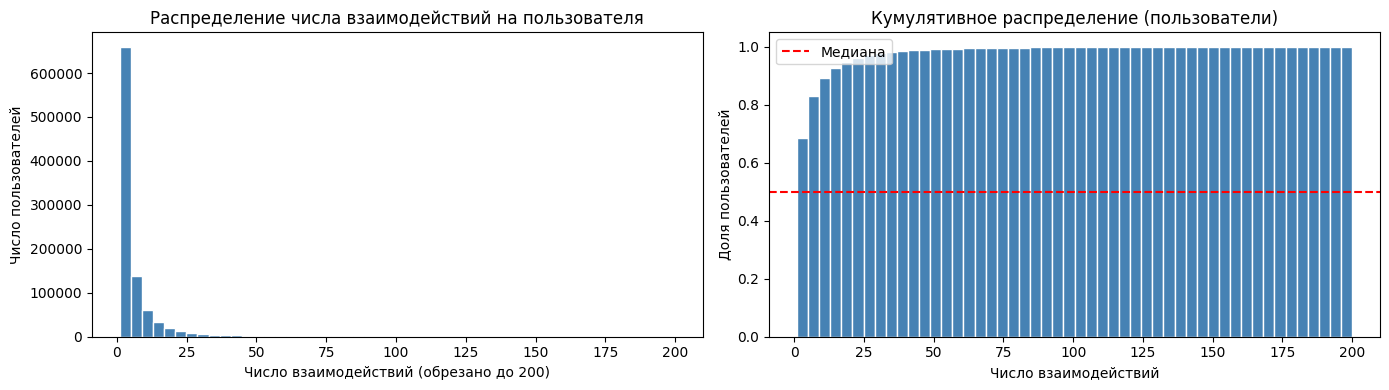

Пользователей с <  1 взаимодействий: 0 (0.0%)
Пользователей с <  2 взаимодействий: 355,163 (36.9%)
Пользователей с <  5 взаимодействий: 659,693 (68.6%)
Пользователей с < 10 взаимодействий: 816,769 (84.9%)


In [ ]:
user_activity = inter_df.groupby(user_col)[item_col].count().rename('n_interactions')

print("Статистика по числу взаимодействий на пользователя:")
print(user_activity.describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_activity.clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение числа взаимодействий на пользователя')
axes[0].set_xlabel('Число взаимодействий (обрезано до 200)')
axes[0].set_ylabel('Число пользователей')

axes[1].hist(user_activity.clip(upper=200), bins=50, color='steelblue',
             edgecolor='white', cumulative=True, density=True)
axes[1].set_title('Кумулятивное распределение (пользователи)')
axes[1].set_xlabel('Число взаимодействий')
axes[1].set_ylabel('Доля пользователей')
axes[1].axhline(0.5, color='red', linestyle='--', label='Медиана')
axes[1].legend()

plt.tight_layout()
plt.show()

# доля холодных пользователей
for threshold in [1, 2, 5, 10]:
    cold = (user_activity < threshold).sum()
    print(f"Пользователей с < {threshold:>2} взаимодействий: {cold:,} ({cold/n_users:.1%})")

Популярность фильмов (long-tail):

Статистика по числу пользователей на фильм:
count     15706.00
mean        348.67
std        3194.05
min           1.00
25%           3.00
50%          12.00
75%          99.00
90%         606.00
95%        1313.50
99%        4687.70
max      202457.00
Name: n_users, dtype: float64


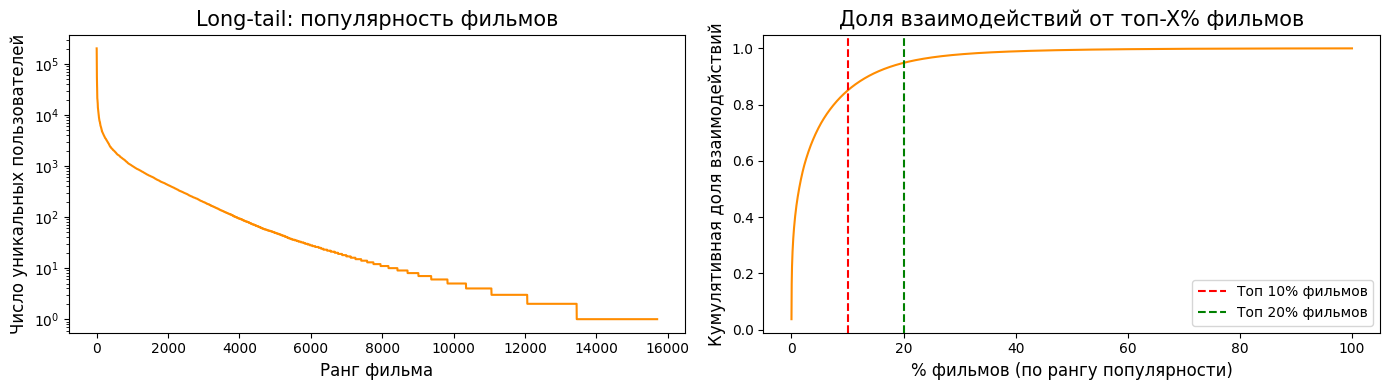

Топ 10% фильмов покрывают 85.0% взаимодействий
Топ 20% фильмов покрывают 94.9% взаимодействий


In [ ]:
item_popularity = inter_df.groupby(item_col)[user_col].count().rename('n_users').sort_values(ascending=False)

print("Статистика по числу пользователей на фильм:")
print(item_popularity.describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(len(item_popularity)), item_popularity.values, color='darkorange')
axes[0].set_title('Long-tail: популярность фильмов', fontsize=15)
axes[0].set_xlabel('Ранг фильма', fontsize=12)
axes[0].set_ylabel('Число уникальных пользователей', fontsize=12)
axes[0].set_yscale('log')

# Доля взаимодействий на топ-N% фильмов
cumsum = item_popularity.cumsum() / item_popularity.sum()
top10_pct_idx = int(len(item_popularity) * 0.1)
top20_pct_idx = int(len(item_popularity) * 0.2)

axes[1].plot(np.linspace(0, 100, len(cumsum)), cumsum.values, color='darkorange')
axes[1].set_title('Доля взаимодействий от топ-X% фильмов', fontsize=15)
axes[1].set_xlabel('% фильмов (по рангу популярности)', fontsize=12)
axes[1].set_ylabel('Кумулятивная доля взаимодействий', fontsize=12)
axes[1].axvline(10, color='red', linestyle='--', label=f"Топ 10% фильмов")
axes[1].axvline(20, color='green', linestyle='--', label=f"Топ 20% фильмов")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Топ 10% фильмов покрывают {cumsum.iloc[top10_pct_idx]:.1%} взаимодействий")
print(f"Топ 20% фильмов покрывают {cumsum.iloc[top20_pct_idx]:.1%} взаимодействий")

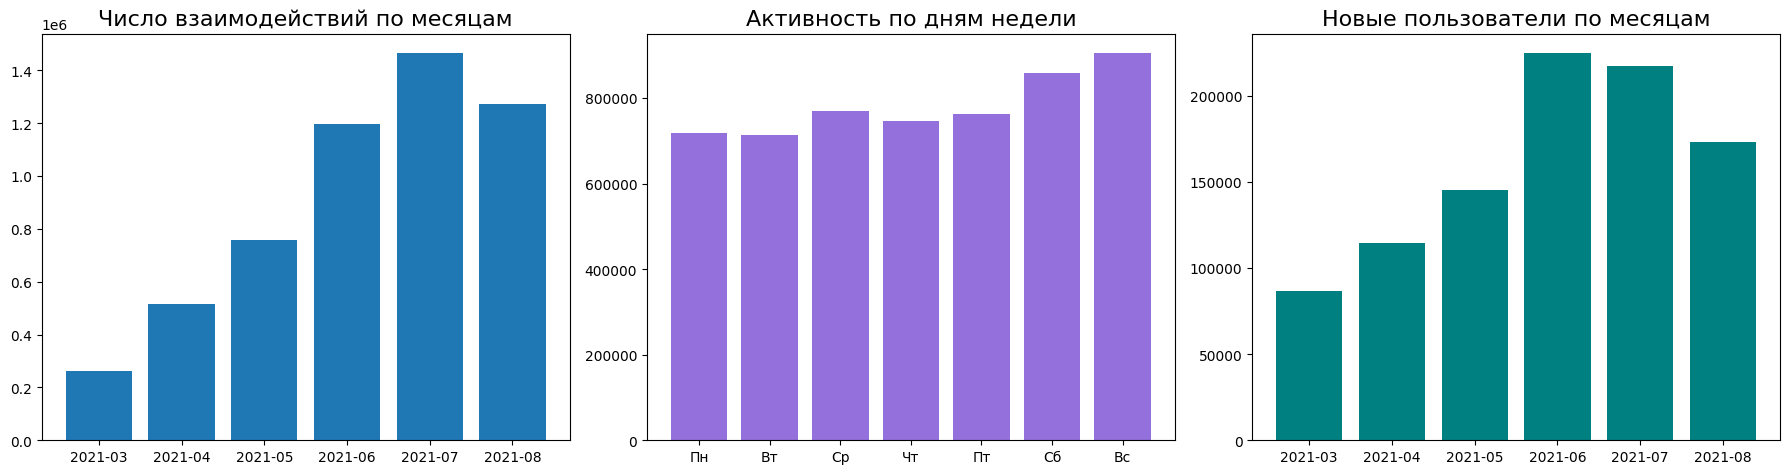

In [ ]:
inter_df[time_col] = pd.to_datetime(inter_df[time_col])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# По месяцам
monthly = inter_df.groupby(inter_df[time_col].dt.to_period('M')).size()
axes[0].bar(monthly.index.astype(str), monthly.values)
axes[0].set_title('Число взаимодействий по месяцам', fontsize=16)

# По дням недели
dow_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
dow = inter_df.groupby(inter_df[time_col].dt.dayofweek).size()
axes[1].bar(dow_labels[:len(dow)], dow.values, color='mediumpurple')
axes[1].set_title('Активность по дням недели', fontsize=16)

# Новые пользователи
first_seen = inter_df.groupby(user_col)[time_col].min()
new_users_monthly = first_seen.dt.to_period('M').value_counts().sort_index()
axes[2].bar(new_users_monthly.index.astype(str),
            new_users_monthly.values, color='teal')
axes[2].set_title('Новые пользователи по месяцам', fontsize=16)

plt.tight_layout()
plt.show()

Анализ профилей пользователей:

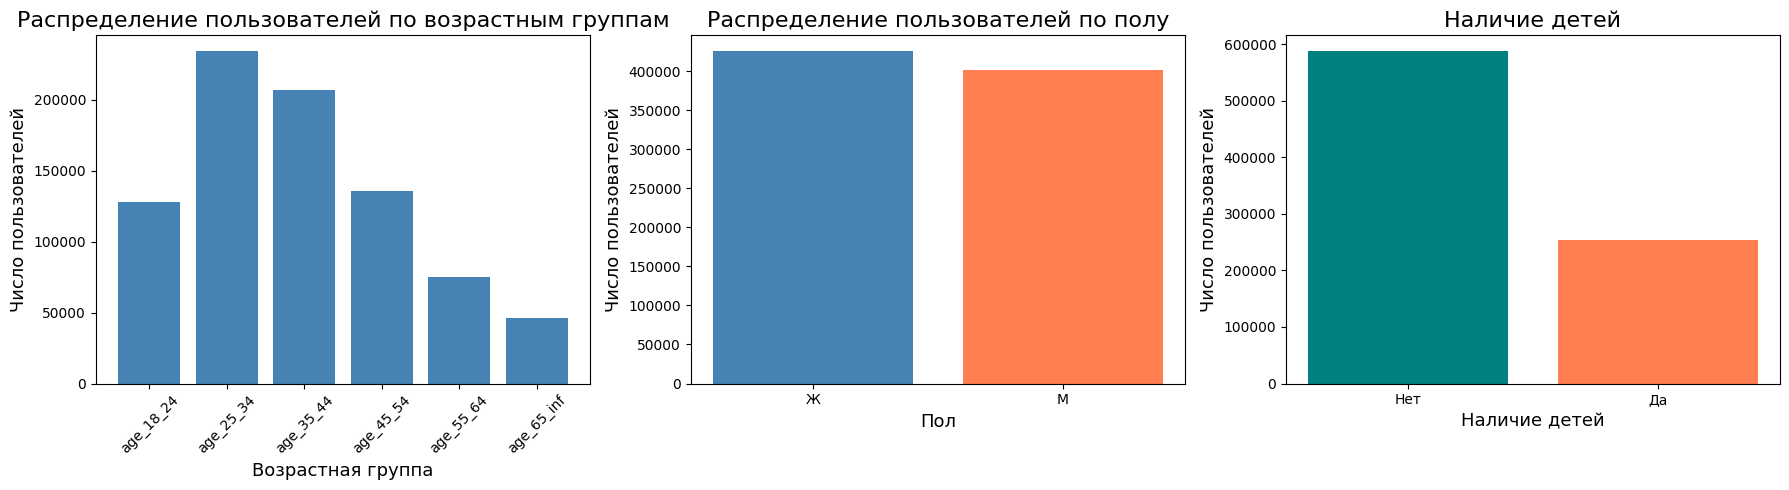

Числовые признаки пользователей:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,840197.0,NaN,NaN,NaN,548766.797349,316884.134955,0.0,274099.0,548808.0,823238.0,1097558.0
age,826102,6,age_25_34,233926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,825421,6,income_20_40,471519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,826366,2,Ж,425270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kids_flg,840197.0,NaN,NaN,NaN,0.301106,0.458739,0.0,0.0,0.0,1.0,1.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Возрастные группы
age_counts = user_df['age'].value_counts().sort_index()

axes[0].bar(age_counts.index, age_counts.values, color='steelblue')
axes[0].set_title('Распределение пользователей по возрастным группам', fontsize=16)
axes[0].set_xlabel('Возрастная группа', fontsize=13)
axes[0].set_ylabel('Число пользователей', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

# Пол
gender_counts = user_df['sex'].value_counts()

axes[1].bar(gender_counts.index, gender_counts.values, color=['steelblue', 'coral'])
axes[1].set_title('Распределение пользователей по полу', fontsize=16)
axes[1].set_xlabel('Пол', fontsize=13)
axes[1].set_ylabel('Число пользователей', fontsize=13)

# Наличие детей
kids_counts = user_df['kids_flg'].value_counts().sort_index()

axes[2].bar(['Нет', 'Да'], kids_counts.values, color=['teal', 'coral'])
axes[2].set_title('Наличие детей', fontsize=16)
axes[2].set_xlabel('Наличие детей', fontsize=13)
axes[2].set_ylabel('Число пользователей', fontsize=13)

plt.tight_layout()
plt.show()

print("Числовые признаки пользователей:")
display(user_df.describe(include='all').T)

Анализ каталога фильмов:

Типы контента:
content_type
film      12002
series     3961



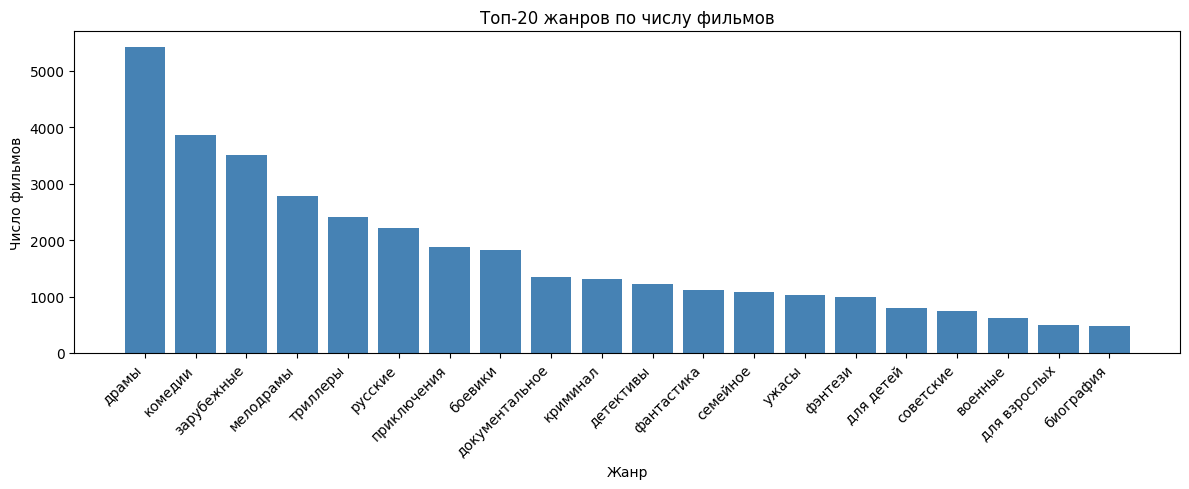

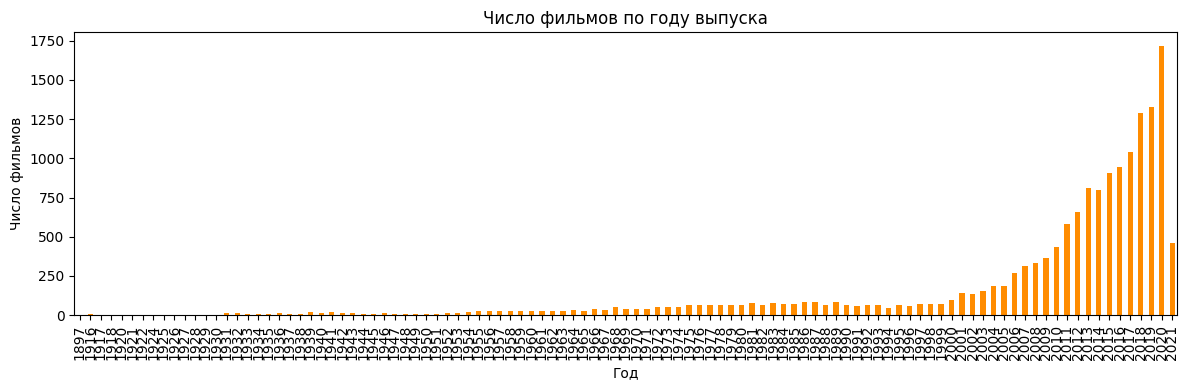

In [ ]:
# Тип контента
if 'content_type' in item_df.columns:
    ct = item_df['content_type'].value_counts()
    print("Типы контента:")
    print(ct.to_string())
    print()

# Жанры
genre_col = None
for col in ['genres', 'genre', 'genres_en']:
    if col in item_df.columns:
        genre_col = col
        break

if genre_col:
    all_genres = item_df[genre_col].dropna().str.split(',').explode().str.strip().value_counts()

    top_genres = all_genres.head(20)
    plt.figure(figsize=(12, 5))
    plt.bar(top_genres.index, top_genres.values, color='steelblue')
    plt.title('Топ-20 жанров по числу фильмов')
    plt.xlabel('Жанр')
    plt.ylabel('Число фильмов')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Год производства
year_col = None
for col in ['year', 'release_year', 'release_date']:
    if col in item_df.columns:
        year_col = col
        break

if year_col:
    plt.figure(figsize=(12, 4))
    item_df[year_col].dropna().astype(int).value_counts().sort_index().plot(kind='bar', color='darkorange')
    plt.title('Число фильмов по году выпуска')
    plt.xlabel('Год')
    plt.ylabel('Число фильмов')
    plt.tight_layout()
    plt.show()

Итоговая сводка EDA

In [ ]:
print("СВОДКА ПО ДАТАСЕТУ\n")
print(f"Пользователей: {user_df[user_col].nunique():,}")
print(f"Фильмов в каталоге: {item_df[item_col].nunique():,}")
print(f"Всего взаимодействий: {len(inter_df):,}")
print(f"Разреженность: {sparsity:.4%}")
print(f"Период данных: {inter_df[time_col].min().date()} - {inter_df[time_col].max().date()}")
print(f"Медиана активности: {user_activity.median():.0f} просмотров/пользователь")
print(f"Медиана популярности: {item_popularity.median():.0f} пользователей/фильм")
print(f"Доля пропусков users: {user_df.isnull().mean().mean():.2%}")
print(f"Доля пропусков items: {item_df.isnull().mean().mean():.2%}")
print(f"Доля пропусков inter: {inter_df.isnull().mean().mean():.2%}")

СВОДКА ПО ДАТАСЕТУ

Пользователей: 840,197
Фильмов в каталоге: 15,963
Всего взаимодействий: 5,476,251
Разреженность: 99.9638%
Период данных: 2021-03-13 - 2021-08-22
Медиана активности: 2 просмотров/пользователь
Медиана популярности: 12 пользователей/фильм
Доля пропусков users: 1.02%
Доля пропусков items: 17.78%
Доля пропусков inter: 0.00%


# Предобработка: бинарный признак просмотра

`watched_pct` - процент просмотра фильма пользователем. Показывает, какую долю от общей длины фильма пользователь посмотрел.

**Порог 50 процентов** - просмотр менее 50% фильма считается отсутствие интереса у пользователя.

In [ ]:
inter_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [ ]:
WATCH_THRESHOLD_SEC = 50

inter_df['watched'] = (inter_df['watched_pct'] >= WATCH_THRESHOLD_SEC).astype(int)

print(f'Всего взаимодействий: {len(inter_df):>10,}')
print(f'Реальных просмотров (>= {WATCH_THRESHOLD_SEC} сек): {inter_df["watched"].sum():>10,}')
print(f'Доля реальных просмотров: {inter_df["watched"].mean():>10.2%}')

watched_df = inter_df[inter_df['watched'] == 1].copy()
print(f'\nwatched_df: {len(watched_df):,} строк | {watched_df[user_col].nunique():,} пользователей | {watched_df[item_col].nunique():,} фильмов')

Всего взаимодействий:  5,476,251
Реальных просмотров (>= 50 сек):  2,416,400
Доля реальных просмотров:     44.13%

watched_df: 2,416,400 строк | 580,075 пользователей | 12,664 фильмов


# Train / Test split (хронологический)

**Стратегия:** для каждого пользователя последние 20% взаимодействий по дате → в тест, остальные → в трейн.

Это имитирует реальную задачу: модель обучается на прошлом и предсказывает будущее.
Пользователи с менее чем 5 просмотрами исключаются - для них нельзя построить надёжный профиль.

In [ ]:
watched_df[time_col] = pd.to_datetime(watched_df[time_col])
watched_df = watched_df.sort_values([user_col, time_col]).reset_index(drop=True)

print(f'Диапазон дат: {watched_df[time_col].min().date()} - {watched_df[time_col].max().date()}')

def train_test_split_by_user(df, test_size=0.2, min_interactions=5):
    user_counts = df.groupby(user_col)[item_col].count()
    valid_users = user_counts[user_counts >= min_interactions].index
    df = df[df[user_col].isin(valid_users)].copy()
    print(f'Пользователей после фильтрации (>= {min_interactions} просмотров): {len(valid_users):,}')

    train_list, test_list = [], []
    for user, group in df.groupby(user_col):
        n_test = max(1, int(len(group) * test_size))
        train_list.append(group.iloc[:-n_test])
        test_list.append(group.iloc[-n_test:])

    return (pd.concat(train_list).reset_index(drop=True),
            pd.concat(test_list).reset_index(drop=True))

train_df, test_df = train_test_split_by_user(watched_df, test_size=0.2, min_interactions=5)

print(f'\nTrain: {len(train_df):,} взаимодействий | {train_df[user_col].nunique():,} пользователей')
print(f'Test:  {len(test_df):,} взаимодействий | {test_df[user_col].nunique():,} пользователей')

Диапазон дат: 2021-03-13 - 2021-08-22
Пользователей после фильтрации (>= 5 просмотров): 138,159

Train: 1,350,999 взаимодействий | 138,159 пользователей
Test:  283,805 взаимодействий | 138,159 пользователей


# Функции оценки метрик

Для проверки статистической значимости получаемых метрик, воспользуемся бутстреп-методом и будет смотреть на доверительные интервалы:

In [ ]:
def bootstrap_ci(values, confidence=0.95, n_bootstrap=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.asarray(values)
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = rng.choice(values, size=len(values), replace=True)
        bootstrap_means.append(np.mean(sample))
    alpha = 1 - confidence

    lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
    return round(lower, 4), round(upper, 4)

Используемые метрики:

- **Precision@K** - доля релевантных среди K рекомендованных
- **Recall@K** - доля найденных релевантных от всех релевантных
- **NDCG@K** - качество ранжирования с учётом позиции (формулы DCG/NDCG)
- **Catalog coverage** - доля уникальных фильмов из каталога, которые попались пользователям в топ-K рекомендациях
- **Novelty@K** - средняя неожиданность рекомендованных фильмов

In [ ]:
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = sum(1 for item in recommended_k if item in relevant)
    return hits / k

def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / len(relevant)

def ndcg_at_k(recommended, relevant, k):
    relevant_set = set(relevant)
    dcg = sum(
        1.0 / np.log2(i + 2)
        for i, item in enumerate(recommended[:k])
        if item in relevant_set
    )
    n_rel  = min(len(relevant), k)
    idcg   = sum(1.0 / np.log2(i + 2) for i in range(n_rel))
    return dcg / idcg if idcg > 0 else 0.0

def catalog_coverage(all_recommendations: dict, all_item_ids: set, k: int):
    recommended_items = set()
    for recs in all_recommendations.values():
        recommended_items.update(recs[:k])
    return len(recommended_items) / len(all_item_ids) if all_item_ids else 0.0


def novelty_at_k(recommended: list, item_popularity: dict, k: int):
    scores = [-np.log2(item_popularity.get(item, 1e-10) + 1e-10)
              for item in recommended[:k]]
    return np.mean(scores) if scores else 0.0


def evaluate_model(recommend_fn, test_df, train_df, all_item_ids, K=50,
                   sample_users=3000):
    user_col, item_col = "user_id", "item_id"
    # нормированная популярность для novelty
    n_users = train_df[user_col].nunique()
    item_popularity = (
        train_df.groupby(item_col)[user_col].nunique() / n_users
    ).to_dict()

    precisions, recalls, ndcgs, novelties = [], [], [], []
    total_hits, total_relevant = 0, 0
    all_recommendations = {}

    test_users = test_df[user_col].unique()
    if len(test_users) > sample_users:
        np.random.seed(42)
        test_users = np.random.choice(test_users, sample_users, replace=False)

    skipped = 0
    for user in test_users:
        relevant = test_df[test_df[user_col] == user][item_col].tolist()
        train_items = train_df[train_df[user_col] == user][item_col].tolist()
        recommended = recommend_fn(user, train_items, K)

        all_recommendations[user] = recommended

        hits = len(set(recommended[:K]) & set(relevant))

        precisions.append(precision_at_k(recommended, relevant, K))
        recalls.append(recall_at_k(recommended, relevant, K))
        ndcgs.append(ndcg_at_k(recommended, relevant, K))
        novelties.append(novelty_at_k(recommended, item_popularity, K))

        total_hits += hits
        total_relevant += len(relevant)

    micro_recall = total_hits / total_relevant if total_relevant > 0 else 0.0
    coverage = catalog_coverage(all_recommendations, all_item_ids, K)

    print(f'- Оценено: {len(precisions):,}, пропущено: {skipped:,}')

    precision_ci = bootstrap_ci(precisions)
    recall_ci = bootstrap_ci(recalls)
    ndcg_ci = bootstrap_ci(ndcgs)
    novelty_ci = bootstrap_ci(novelties)

    return {
        f'Precision@{K}': round(np.mean(precisions), 4),
        f'Precision@{K}_CI95': precision_ci,

        f'Recall@{K}': round(np.mean(recalls), 4),
        f'Recall@{K}_CI95': recall_ci,

        f'Micro_Recall@{K}': round(micro_recall, 4),

        f'NDCG@{K}': round(np.mean(ndcgs), 4),
        f'NDCG@{K}_CI95': ndcg_ci,

        f'Novelty@{K}': round(np.mean(novelties), 4),
        f'Novelty@{K}_CI95': novelty_ci,

        f'CatalogCoverage@{K}': round(coverage, 4),
    }

В качестве дополнительного сравнения разных моделей посмотрим на их показатели при входных данных разной длины. В связи с распространенностью проблемы на практике, **холодный старт и малую длину истории** лучше оценивать отдельно.

Для этого эксперимента формируются специальные датасеты, содержащие нужные по длине пользовательские истории (длина истории по умолчанию = 2,5,10 - для проверки разных ситуаций):

In [ ]:
def prepare_cold_start_datasets(interactions_df, history_lengths=(2, 5, 10)):
    df = interactions_df.copy()
    df["last_watch_dt"] = pd.to_datetime(df["last_watch_dt"])
    # сортируем один раз по пользователю и времени
    df = df.sort_values(["user_id", "last_watch_dt"]).reset_index(drop=True)
    # создаём ранги внутри каждого пользователя
    df["_rank"] = df.groupby("user_id").cumcount() + 1
    # общее число записей для каждого пользователя (максимальный ранг)
    df["_total"] = df.groupby("user_id")["_rank"].transform("max")

    datasets = {}
    for history_length in history_lengths:
        # пользователи, у которых записей больше history_length
        mask_valid = df["_total"] > history_length

        train_mask = mask_valid & (df["_rank"] <= history_length)
        test_mask  = mask_valid & (df["_rank"] > history_length)

        train_df = df.loc[train_mask].drop(columns=["_rank", "_total"]).reset_index(drop=True)
        test_df  = df.loc[test_mask].drop(columns=["_rank", "_total"]).reset_index(drop=True)

        datasets[history_length] = {"train": train_df, "test":  test_df}

        print(
            f"History={history_length}: "
            f"{train_df['user_id'].nunique():,} users | "
            f"{len(train_df):,} train | "
            f"{len(test_df):,} test"
        )

    return datasets

In [ ]:
cold_datasets = prepare_cold_start_datasets(watched_df, history_lengths=[2, 5, 10])

History=2: 237,104 users | 474,208 train | 1,496,623 test
History=5: 111,045 users | 555,225 train | 944,009 test
History=10: 47,729 users | 477,290 train | 546,444 test


Для эксперимента с холодным стартом используется отдельная функция оценивания для получения результатов сразу по всем установленым настройкам длины пользовательской истории; функция также учитывает, что для некоторых моделей потребуется refitting.

In [ ]:
def evaluate_cold_start_model(model, datasets, all_item_ids, user_col="user_id",
                              item_col="item_id", K=20, sample_users=3000,
                              refit=True):

    results = []
    for history_length, data in datasets.items():
        train_df = data["train"]
        test_df = data["test"]
        print(f"\nHistory length = {history_length}")
        if refit:
            model.fit(train_df, user_col=user_col, item_col=item_col)

        metrics = evaluate_model(
            recommend_fn=model.recommend,
            train_df=train_df,
            test_df=test_df,
            all_item_ids=all_item_ids,
            K=K,
            sample_users=sample_users
        )
        metrics["HistoryLength"] = history_length
        results.append(metrics)
    return results

In [ ]:
all_item_ids = set(item_df["item_id"])

# Бейзлайн 1: Топ популярных (глобальный)

**Идея:** рекомендуем всем пользователям одинаковый список - самые популярные фильмы по всей аудитории.

Это **нижняя планка**: любая персонализированная модель должна показать метрики выше.

**Скор популярности** = `num_users x avg_dur` - учитывает и охват, и вовлечённость.

In [ ]:
# строим ТОЛЬКО по train_df - без утечки данных из теста
popular_df = train_df.groupby(item_col).agg(
    num_users=(user_col, 'nunique'),
    avg_dur  =('watched_pct', 'mean')).reset_index()

popular_df['score'] = popular_df['num_users'] * popular_df['avg_dur']
popular_df = popular_df.sort_values('score', ascending=False).reset_index(drop=True)

if 'title' in item_df.columns:
    popular_df = popular_df.merge(item_df[['item_id','title','genres',
                                           'content_type', 'release_year']], on='item_id', how='left')

global_popular_items = popular_df[item_col].tolist()
print(f'Уникальных объектов: {len(popular_df):,}')
popular_df.head(10)

Уникальных объектов: 11,776


,item_id,num_users,avg_dur,score,title,genres,content_type,release_year
0,13865,32511,96.553320,3139045.0,Девятаев,"драмы, военные, приключения",film,2021.0
1,9728,30186,95.824588,2892561.0,Гнев человеческий,"боевики, триллеры",film,2021.0
2,10440,28890,87.454829,2526570.0,Хрустальный,"триллеры, детективы",series,2021.0
3,3734,22954,96.033415,2204351.0,Прабабушка легкого поведения,комедии,film,2021.0
4,15297,25509,85.672508,2185420.0,Клиника счастья,"драмы, мелодрамы",series,2021.0
5,142,15476,95.477320,1477607.0,Маша,"драмы, триллеры",film,2020.0
6,4151,14563,88.734739,1292244.0,Секреты семейной жизни,комедии,series,2021.0
7,8636,12215,96.376832,1177243.0,Белый снег,"драмы, спорт",film,2021.0
8,1844,8737,96.475335,842905.0,Аферистка,"триллеры, комедии",film,2020.0
9,11237,8524,94.959174,809432.0,День города,комедии,film,2021.0


Топ-N самых популярных, исключая уже просмотренные:

In [ ]:
def recommend_popular_fn(user_id, train_items, n):
    train_set = set(train_items)
    return [i for i in global_popular_items if i not in train_set][:n]

print(f'Оцениваем Бейзлайн 1 (Топ популярных) @ K={K}...')
b1_metrics = evaluate_model(recommend_popular_fn, test_df, train_df, all_item_ids, K=K)
print('Результат:')
for m, v in b1_metrics.items():
    print(f'  {m}: {v}')

Оцениваем Бейзлайн 1 (Топ популярных) @ K=10...
- Оценено: 3,000, пропущено: 0
Результат:
  Precision@10: 0.0286
  Precision@10_CI95: (np.float64(0.0267), np.float64(0.0305))
  Recall@10: 0.1832
  Recall@10_CI95: (np.float64(0.1716), np.float64(0.1964))
  Micro_Recall@10: 0.1377
  NDCG@10: 0.1147
  NDCG@10_CI95: (np.float64(0.1072), np.float64(0.1236))
  Novelty@10: 3.1715
  Novelty@10_CI95: (np.float64(3.1621), np.float64(3.1811))
  CatalogCoverage@10: 0.0014


In [ ]:
popular_df.to_csv('popular.csv', index=False)

Расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
class PopularityWrapper:
    def __init__(self, recommend_function):
        self.recommend_function = recommend_function

    def fit(self, train_df):
        return self

    def recommend(self, user_id, train_items, n):
        return self.recommend_function(user_id, train_items, n)

pop_model = PopularityWrapper(recommend_popular_fn)

In [ ]:
cold_popularity = evaluate_cold_start_model(
    model=pop_model,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    K=20,
    refit=False
)


History length = 2
- Оценено: 3,000, пропущено: 0

History length = 5
- Оценено: 3,000, пропущено: 0

History length = 10
- Оценено: 3,000, пропущено: 0


# Бейзлайн 2: Топ популярных по жанрам

**Идея:** персонализируем бейзлайн по жанровым предпочтениям.
Определяем любимые жанры пользователя по истории просмотров → рекомендуем топ популярных фильмов в этих жанрах.

Если топ-популярный работает хорошо, то популярные фильмы сосредоточены в узком диапазоне.

In [ ]:
item_genres = (
    item_df[['item_id','genres']]
    .dropna(subset=['genres'])
    .copy()
)
item_genres['genre'] = item_genres['genres'].str.split(', ')
item_genres = item_genres.explode('genre')
item_genres['genre'] = item_genres['genre'].str.strip().str.lower()
item_genres = item_genres[item_genres['genre'] != '']

print(f'Уникальных жанров: {item_genres["genre"].nunique()}')
print('Топ-10 жанров:')
print(item_genres['genre'].value_counts().head(10).to_string())

Уникальных жанров: 95
Топ-10 жанров:
genre
драмы             5431
комедии           3858
зарубежные        3503
мелодрамы         2778
триллеры          2418
русские           2216
приключения       1877
боевики           1820
документальное    1339
криминал          1306


In [ ]:
train_with_genres = train_df.merge(item_genres[['item_id','genre']], on='item_id', how='left')

popular_by_genre = train_with_genres.groupby(['genre', item_col]).agg(
    num_users=(user_col, 'nunique'),
    avg_dur  =('watched_pct', 'mean')).reset_index()

popular_by_genre['score'] = popular_by_genre['num_users'] * popular_by_genre['avg_dur']
popular_by_genre = popular_by_genre.sort_values(['genre','score'], ascending=[True, False])

genre_top_items = popular_by_genre.groupby('genre')[item_col].apply(list).to_dict()

item_to_genres = item_genres.groupby('item_id')['genre'].apply(list).to_dict()

print(f'Жанров с топ-листами: {len(genre_top_items)}')
print('Пример (драмы, топ-5):')
for iid in genre_top_items.get('драмы', [])[:5]:
    title = item_df[item_df['item_id'] == iid]['title'].values
    print(f'  {iid}: {title[0] if len(title) else "-"}')

Жанров с топ-листами: 84
Пример (драмы, топ-5):
  13865: Девятаев
  15297: Клиника счастья
  142: Маша
  8636: Белый снег
  4457: 2067: Петля времени


In [ ]:
print('Пример (комедии, топ-5):')
for iid in genre_top_items.get('комедии', [])[:5]:
    title = item_df[item_df['item_id'] == iid]['title'].values
    print(f'  {iid}: {title[0] if len(title) else "-"}')

Пример (комедии, топ-5):
  3734: Прабабушка легкого поведения
  4151: Секреты семейной жизни
  1844: Аферистка
  11237: День города
  7571: 100% волк


In [ ]:
def recommend_popular_by_genre(user_id, train_items, n):
    train_set = set(train_items)
    # жанры пользователя, отсортированные по частоте
    user_genre_counts = {}
    for item_id in train_items:
        for g in item_to_genres.get(item_id, []):
            user_genre_counts[g] = user_genre_counts.get(g, 0) + 1
    user_genres = sorted(user_genre_counts, key=user_genre_counts.get, reverse=True)

    recommendations, seen = [], set()

    for genre in user_genres:
        for item_id in genre_top_items.get(genre, []):
            if item_id not in train_set and item_id not in seen:
                recommendations.append(item_id)
                seen.add(item_id)
            if len(recommendations) == n:
                return recommendations

    # Cold-start
    for item_id in global_popular_items:
        if item_id not in train_set and item_id not in seen:
            recommendations.append(item_id)
        if len(recommendations) == n:
            break

    return recommendations

print(f'Оцениваем Бейзлайн 2 (Топ по жанрам) @ K={K}...')
b2_metrics = evaluate_model(recommend_popular_by_genre, test_df, train_df, all_item_ids, K=K)
print('Результат:')
for m, v in b2_metrics.items():
    print(f'  {m}: {v}')

Оцениваем Бейзлайн 2 (Топ по жанрам) @ K=10...
- Оценено: 3,000, пропущено: 0
Результат:
  Precision@10: 0.0177
  Precision@10_CI95: (np.float64(0.0164), np.float64(0.0192))
  Recall@10: 0.1002
  Recall@10_CI95: (np.float64(0.0907), np.float64(0.1102))
  Micro_Recall@10: 0.0853
  NDCG@10: 0.074
  NDCG@10_CI95: (np.float64(0.0669), np.float64(0.0811))
  Novelty@10: 4.6444
  Novelty@10_CI95: (np.float64(4.6206), np.float64(4.669))
  CatalogCoverage@10: 0.0136


Расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
class PopularityGenresWrapper:
    def __init__(self, recommend_popular_by_genre):
        self.recommend_popular_by_genre = recommend_popular_by_genre

    def fit(self, train_df):
        return self

    def recommend(self, user_id, train_items, n):
        return self.recommend_popular_by_genre(user_id, train_items, n)

pop_genres = PopularityGenresWrapper(recommend_popular_by_genre)

In [ ]:
cold_genres = evaluate_cold_start_model(
    model=pop_genres,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    K=20,
    refit=False
)


History length = 2
- Оценено: 3,000, пропущено: 0

History length = 5
- Оценено: 3,000, пропущено: 0

History length = 10
- Оценено: 3,000, пропущено: 0


# Контентная фильтрация

## Контентная фильтрация с TF-IDF и алгоритмом Роккио

Реализует подход VSM из раздела 1.1.1 теоретической части:

1. **Представление объектов** - TF-IDF векторы по тексту метаданных (жанры, ключевые слова, описание, режиссёр, актёры)
2. **Профиль пользователя** - алгоритм Роккио: взвешенное среднее TF-IDF векторов просмотренных фильмов, вес = `total_dur` (неявный фидбек)
3. **Мера сходства** - косинусная близость профиля пользователя и вектора фильма



Эмбеддинг каждого объекта формируется путём объединения таких текстовых признаков, как `genres`, `keywords`, `description`, `directors`, `actors`, `content_type`, `countries`, причём для отдельных признаков экспериментально задаются различные «веса»: поля `keywords`, `description` и `actors` включаются в итоговый текст *дважды*, тем самым увеличивая их вклад при векторизации.



Полученные тексты преобразуются в векторное представление с помощью **TF-IDF**:

$$
TF\text{-}IDF(t_k, d_j) = TF(t_k, d_j) \cdot \log \frac{N}{n_k},
$$

где $TF(t_k, d_j)$ — частота термина $t_k$ в документе $d_j$, $N$ — общее число документов, а $n_k$ — количество документов, содержащих термин $t_k$.



После этого профиль пользователя определяется как среднее значение векторов объектов из его истории взаимодействий:

$$
\bar{u_i} = \frac{1}{|I_i|} \sum_{\lambda \in I_i} \bar{v_{\lambda}},
$$

где $I_i$ — множество объектов, понравившихся пользователю $i$, а $\bar{v_{\lambda}}$ — TF-IDF-вектор объекта $\lambda$.

In [ ]:
def build_item_text(row):
    parts = []
    if pd.notna(row['genres']):
        parts.append(str(row['genres']))

    if pd.notna(row['keywords']):
        parts += [str(row['keywords'])] * 2

    if pd.notna(row['description']):
        parts += [str(row['description'])] * 2

    if pd.notna(row['directors']):
        parts.append(str(row['directors']))

    if pd.notna(row['actors']):
        parts += [str(row['actors'])] * 2

    if pd.notna(row['content_type']):
        parts.append(str(row['content_type']))

    if pd.notna(row['countries']):
        parts.append(str(row['countries']))

    return ' '.join(parts).lower()

item_df_cbf = item_df[[
    'item_id','content_type','title',
    'genres','keywords','description','directors','actors', 'countries'
]].copy()

item_df_cbf['text'] = item_df_cbf.apply(build_item_text, axis=1)
item_df_cbf = item_df_cbf[
    item_df_cbf['text'].str.strip() != ''
].reset_index(drop=True)


print(f'Фильмов с текстовыми признаками: {len(item_df_cbf):,}')
print('\nПример текста для 2 фильмов:')
for _, row in item_df_cbf.head(2).iterrows():
    print(f"  [{row['item_id']}] {row['title']}")
    print(f"  → {row['text'][:180]}...")

Фильмов с текстовыми признаками: 15,963

Пример текста для 2 фильмов:
  [10711] Поговори с ней
  → драмы, зарубежные, детективы, мелодрамы поговори, ней, 2002, испания, друзья, любовь, сильные, женщины, преодоление, трудностей, отношения, дружба, отношения, паре, отношения, мужч...
  [2508] Голые перцы
  → зарубежные, приключения, комедии голые, перцы, 2014, сша, друзья, свадьбы, преодоление, трудностей, расставания, отношения, дружба, риск, недоразумение, мужская, дружба, мальчишник...


In [ ]:
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    analyzer='word',
    ngram_range=(1, 1),
    min_df=2,
    max_features=15000,
    token_pattern=r'[а-яёa-z][а-яёa-z\-]{1,}'
)

tfidf_matrix = tfidf.fit_transform(item_df_cbf['text'])
print(f'TF-IDF матрица: {tfidf_matrix.shape}  (объекты х признаки)')
print(f'Размер словаря: {len(tfidf.get_feature_names_out()):,}')
print(f'Примеры признаков: {list(tfidf.get_feature_names_out()[:15])}')

item_ids_cbf = item_df_cbf['item_id'].tolist()
item_to_idx  = {iid: idx for idx, iid in enumerate(item_ids_cbf)}
idx_to_item  = {idx: iid for idx, iid in enumerate(item_ids_cbf)}

TF-IDF матрица: (15963, 15000)  (объекты х признаки)
Размер словаря: 15,000
Примеры признаков: ['afc', 'apple', 'baby', 'bell', 'cgi-анимация', 'codim', 'com', 'd-анимация', 'dance', 'e-mail', 'explorers', 'facebook', 'film', 'fox', 'genre']


In [ ]:
def recommend_content_based(user_id, train_items, n):
    train_set = set(train_items)

    known = [(iid, item_to_idx[iid]) for iid in train_items if iid in item_to_idx]

    if not known:
        return [i for i in global_popular_items if i not in train_set][:n]

    indices = [idx for _, idx in known]

    # Равные веса - все взаимодействия уже отфильтрованы как позитивные
    weights = np.ones(len(indices), dtype=float)
    weights /= weights.sum()

    user_profile = sp.csr_matrix(weights).dot(tfidf_matrix[indices])

    sim_scores  = cosine_similarity(user_profile, tfidf_matrix).flatten()
    top_indices = np.argsort(sim_scores)[::-1]

    recs = []
    for idx in top_indices:
        iid = idx_to_item[idx]
        if iid not in train_set:
            recs.append(iid)
        if len(recs) == n:
            break
    return recs

In [ ]:
# пример рекомендаций для одного пользователя
test_user = test_df[user_col].iloc[0]
train_ex  = train_df[train_df[user_col] == test_user][item_col].tolist()
test_ex = test_df[test_df[user_col] == test_user][item_col].tolist()

print(f'Пользователь {test_user} - просмотрел {len(train_ex)} фильмов в трейне')
print('\nПримеры просмотренного в трейне:')
for iid in train_ex[:5]:
    row = item_df[item_df['item_id'] == iid]
    print(f"  {iid}: {row['title'].values[0] if len(row) else '-'} | {row['genres'].values[0] if len(row) else '-'}")

print('\nПримеры просмотренного в тесте:')
for iid in test_ex:
    row = item_df[item_df['item_id'] == iid]
    print(f"  {iid}: {row['title'].values[0] if len(row) else '-'} | {row['genres'].values[0] if len(row) else '-'}")

recs_cbf = recommend_content_based(test_user, train_ex, 10)
print('\nРекомендации (контентная фильтрация):')
for rank, iid in enumerate(recs_cbf, 1):
    row = item_df[item_df['item_id'] == iid]
    print(f"  {rank:2}. [{iid}] {row['title'].values[0] if len(row) else '-'} | {row['genres'].values[0] if len(row) else '-'}")

Пользователь 2 - просмотрел 34 фильмов в трейне

Примеры просмотренного в трейне:
  7571: 100% волк | мультфильм, приключения, семейное, фэнтези, комедии
  11577: Альфа и омега | мелодрамы, мультфильм, приключения, комедии
  16166: Зверополис | приключения, мультфильм, детективы, комедии
  4475: Тачки | спорт, мультфильм, комедии
  6774: Тачки 2 | мультфильм, комедии

Примеры просмотренного в тесте:
  7921: Пушистые мошенники | мультфильм, приключения, комедии
  5819: Реальная белка | мультфильм, криминал, приключения, комедии
  12449: Стражи Арктики | мультфильм, приключения, комедии
  3628: Зверопой | мультфильм, музыкальные, комедии
  242: Сказ о Петре и Февронии | мультфильм, комедии
  9164: ВАЛЛ-И | фантастика, мультфильм, приключения
  13867: Рио | мультфильм, криминал, приключения, мюзиклы, комедии
  16029: Монстр в Париже | мультфильм, музыкальные, приключения, мелодрамы, фэнтези, комедии

Рекомендации (контентная фильтрация):
   1. [463] Дракула | боевики, драмы, фэнтези, ужас

Этот пример демонстрирует поведение модели для пользователя, отдающего явное предпочтение анимационным фильмам - все пять обучающих примеров относятся к жанру анимации, охватывая приключенческие комедии и семейный контент. Тестовый набор у пользователя состоит исключительно из анимационных фильмов в различных поджанрах, включая музыкальные, приключенческие и комедийные, что подтверждает эту закономерность.

Однако рекомендации, основанные на содержании, не могут эффективно отразить это предпочтение. Только 3 из 10 рекомендованных лотов - анимационные фильмы ("Брат медвешонок", "Рек 2", "Алджа"), в то время как остальные 7 - это фэнтези и боевики, такие как "Дракула", "Тор" и "Лиди Икс".

In [ ]:
print(f'Оцениваем Алгоритм 1 (Контентная фильтрация) @ K={K}...')
cbf_metrics = evaluate_model(recommend_content_based, test_df, train_df, all_item_ids, K=K)
print('Результат:')
for m, v in cbf_metrics.items():
    print(f'  {m}: {v}')

Оцениваем Алгоритм 1 (Контентная фильтрация) @ K=10...
- Оценено: 3,000, пропущено: 0
Результат:
  Precision@10: 0.0105
  Precision@10_CI95: (np.float64(0.0093), np.float64(0.0116))
  Recall@10: 0.0707
  Recall@10_CI95: (np.float64(0.0626), np.float64(0.0793))
  Micro_Recall@10: 0.0504
  NDCG@10: 0.038
  NDCG@10_CI95: (np.float64(0.0333), np.float64(0.0429))
  Novelty@10: 12.2974
  Novelty@10_CI95: (np.float64(12.1721), np.float64(12.4166))
  CatalogCoverage@10: 0.2433


Расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
class TFIDFWrapper:
    def __init__(self, recommend_function):
        self.recommend_function = recommend_function

    def fit(self, train_df):
        return self

    def recommend(self, user_id, train_items, n):
        return self.recommend_function(user_id, train_items, n)

tfidf_model = TFIDFWrapper(recommend_content_based)


cold_tfidf = evaluate_cold_start_model(
    model=tfidf_model,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    K=20,
    refit=False
)


History length = 2
- Оценено: 3,000, пропущено: 0

History length = 5
- Оценено: 3,000, пропущено: 0

History length = 10
- Оценено: 3,000, пропущено: 0



## Контентная фильтрация с RuBERT-tiny

Данный рекомендательный алгоритм основан на предобученной трансформерной модели для получения эмбеддингов предложений. Каждый объект представляется вектором, построенным на основе его текстового описания (`description`). Во время формирования рекомендаций создаётся профиль пользователя путём агрегации эмбеддингов ранее просмотренных объектов, после чего кандидаты ранжируются по значению косинусного сходства между пользовательским вектором и векторами всех объектов каталога.

Особенности реализации:

- максимальная длина входного текста ограничена **100 токенами**, что позволяет сократить вычислительные затраты;
- поддерживаются две стратегии построения пользовательского профиля:
  - `mean` — простое усреднение эмбеддингов просмотренных объектов;
  - `weighted` — взвешенное усреднение, где веса определяются значением признака `watched_pct`;
- вычисление релевантности объектов осуществляется посредством одного матрично-векторного произведения:

$$
s_i = V \cdot u^T,
$$

где $V$ — матрица эмбеддингов объектов, а $u$ — вектор пользовательского профиля. Поскольку все эмбеддинги предварительно нормированы, полученное значение эквивалентно косинусному сходству.

**Гиперпараметры модели:**

- `model_name` — идентификатор модели-энкодера из Hugging Face (по умолчанию используется `ai-forever/FRIDA`);
- `batch_size` — размер батча при кодировании текстов (по умолчанию 64);
- `aggregation` — стратегия агрегации пользовательского профиля (`mean` или `weighted`, по умолчанию `mean`).

In [ ]:
class DescriptionEmbeddingRecommender:
    def __init__(self, model_name='ai-forever/FRIDA', batch_size=64, aggregation='mean'):
        self.model_name = model_name
        self.batch_size = batch_size
        self.aggregation = aggregation

        self.encoder = None
        self.item_vectors = None
        self.item2idx = {}
        self.idx2item = {}
        self.user_weights = {}

    def fit(self, item_df: pd.DataFrame, item_col: str = 'item_id',
            text_col: str = 'description'):
        print(f'Загружаем модель: {self.model_name}')
        self.encoder = SentenceTransformer(self.model_name)
        self.encoder.max_seq_length = 100
        df = item_df[[item_col, text_col]].copy()
        # убираем айтемы без описания
        df[text_col] = df[text_col].fillna('').astype(str).str.strip()
        df = df[df[text_col] != ''].reset_index(drop=True)

        self.item2idx = {int(it): i for i, it in enumerate(df[item_col])}
        self.idx2item = {i: int(it) for it, i in self.item2idx.items()}

        texts = df[text_col].tolist()
        print(f'Кодируем {len(texts)} описаний...')

        encode_kwargs = dict(
            batch_size = self.batch_size,
            show_progress_bar = True,
            normalize_embeddings = True,
            convert_to_numpy     = True,
        )

        # FRIDA поддерживает task_type для управления типом эмбеддинга
        if 'FRIDA' in self.model_name:
            encode_kwargs['prompt'] = 'Описание: '  # префикс улучшает качество

        self.item_vectors = self.encoder.encode(texts, **encode_kwargs)
        print(f'Эмбеддинги: {self.item_vectors.shape}')
        return self

    def fit_user_weights(self, train_df, user_col, item_col, weight_col='watched_pct'):
        # загружаем веса для взвешенного профиля пользователя
        for user_id, group in train_df.groupby(user_col):
            w = group.set_index(item_col)[weight_col].astype(float)
            w_min, w_max = w.min(), w.max()
            w = (w - w_min) / (w_max - w_min) if w_max > w_min else w * 0 + 1.0
            self.user_weights[int(user_id)] = {int(k): float(v) for k, v in w.items()}
        print(f'Веса загружены для {len(self.user_weights):,} пользователей')
        return self

    def recommend(self, user_id, train_items, n=10):
        user_id  = int(user_id)
        seen_idx = [self.item2idx[int(i)] for i in train_items
                    if int(i) in self.item2idx]
        if not seen_idx:
            return []

        seen_vectors = self.item_vectors[seen_idx]  # (n_seen, dim)

        # профиль пользователя
        if self.aggregation == 'weighted' and user_id in self.user_weights:
            w = np.array([
                self.user_weights[user_id].get(int(i), 0.0)
                for i in train_items if int(i) in self.item2idx
            ], dtype=np.float32)
            w = w / w.sum() if w.sum() > 0 else np.ones(len(seen_idx)) / len(seen_idx)
            user_profile = (seen_vectors * w[:, None]).sum(axis=0, keepdims=True)
        else:
            user_profile = seen_vectors.mean(axis=0, keepdims=True)

        # так как векторы L2-нормированы - dot product = cosine similarity
        scores = (self.item_vectors @ user_profile.T).ravel()

        scores[seen_idx] = -np.inf
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return [self.idx2item[int(i)] for i in top_idx]

In [ ]:
rubert_cb = DescriptionEmbeddingRecommender(
    model_name = 'cointegrated/rubert-tiny2',
    batch_size = 512,
    aggregation = 'mean',
)
rubert_cb.fit(item_df, item_col='item_id', text_col='description')

Загружаем модель: cointegrated/rubert-tiny2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.40k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Кодируем 15961 описаний...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Эмбеддинги: (15961, 312)


In [ ]:
print(f'Алгоритм 2 (Контентная фильтрация с RuBERT) @ K={K}...')
rubert_metrics = evaluate_model(rubert_cb.recommend, test_df, train_df, all_item_ids, K=K)
print('Результат:')
for m, v in rubert_metrics.items():
    print(f'  {m}: {v}')

Алгоритм 2 (Контентная фильтрация с RuBERT) @ K=10...
- Оценено: 3,000, пропущено: 0
Результат:
  Precision@10: 0.0011
  Precision@10_CI95: (np.float64(0.0007), np.float64(0.0016))
  Recall@10: 0.006
  Recall@10_CI95: (np.float64(0.0038), np.float64(0.0084))
  Micro_Recall@10: 0.0055
  NDCG@10: 0.0032
  NDCG@10_CI95: (np.float64(0.002), np.float64(0.0045))
  Novelty@10: 15.6503
  Novelty@10_CI95: (np.float64(15.5548), np.float64(15.7601))
  CatalogCoverage@10: 0.1315


In [ ]:
# пример рекомендаций для того же пользователя
test_user = test_df[user_col].iloc[0]
train_ex = train_df[train_df[user_col] == test_user][item_col].tolist()
test_ex = test_df[test_df[user_col]   == test_user][item_col].tolist()

print(f"User {test_user} - watched {len(train_ex)} films in train")

print("\nПримеры просмотренного в трейне:")
for iid in train_ex[:5]:
    row = item_df[item_df["item_id"] == iid]
    title  = row["title"].values[0]  if len(row) else "-"
    genres = row["genres"].values[0] if len(row) else "-"
    print(f"  {iid}: {title} | {genres}")

print("\nПримеры просмотренного в тесте:")
for iid in test_ex:
    row = item_df[item_df["item_id"] == iid]
    title  = row["title"].values[0]  if len(row) else "-"
    genres = row["genres"].values[0] if len(row) else "-"
    print(f"  {iid}: {title} | {genres}")

recs_emb = rubert_cb.recommend(test_user, train_ex, n=10)

print("\nПолученные рекомендации (rubert-tiny2):")
for rank, iid in enumerate(recs_emb, 1):
    row = item_df[item_df["item_id"] == iid]
    title  = row["title"].values[0]  if len(row) else "-"
    genres = row["genres"].values[0] if len(row) else "-"
    print(f"  {rank:2}. [{iid}] {title} | {genres}")

hits = set(recs_emb) & set(test_ex)
print(f"\nПопадений в top-10: {len(hits)} / {len(test_ex)}")

User 2 - watched 34 films in train

Примеры просмотренного в трейне:
  7571: 100% волк | мультфильм, приключения, семейное, фэнтези, комедии
  11577: Альфа и омега | мелодрамы, мультфильм, приключения, комедии
  16166: Зверополис | приключения, мультфильм, детективы, комедии
  4475: Тачки | спорт, мультфильм, комедии
  6774: Тачки 2 | мультфильм, комедии

Примеры просмотренного в тесте:
  7921: Пушистые мошенники | мультфильм, приключения, комедии
  5819: Реальная белка | мультфильм, криминал, приключения, комедии
  12449: Стражи Арктики | мультфильм, приключения, комедии
  3628: Зверопой | мультфильм, музыкальные, комедии
  242: Сказ о Петре и Февронии | мультфильм, комедии
  9164: ВАЛЛ-И | фантастика, мультфильм, приключения
  13867: Рио | мультфильм, криминал, приключения, мюзиклы, комедии
  16029: Монстр в Париже | мультфильм, музыкальные, приключения, мелодрамы, фэнтези, комедии

Полученные рекомендации (rubert-tiny2):
   1. [16495] Hot Wheels: Начало приключений | зарубежные, при

Как обсуждалось ранее, пользователь 2 явно отдает предпочтение анимационным комедиям и семейным приключениям; 8 тестовых заданий также соответствуют этому паттерну.

Наша модель правильно распознает жанровый сигнал - 7 из 10 рекомендаций относятся к анимационным фильмам или семейным приключенческим фильмам.

Запуск модели с учетом взвешенного фидбека:

In [ ]:
rubert_cb_w = DescriptionEmbeddingRecommender(
    model_name = 'cointegrated/rubert-tiny2',
    batch_size = 512,
    aggregation = 'weighted',
)
rubert_cb_w.fit(item_df, item_col='item_id', text_col='description')

rubert_cb_w.fit_user_weights(
    train_df,
    user_col='user_id',
    item_col='item_id',
    weight_col='watched_pct'
)

Загружаем модель: cointegrated/rubert-tiny2


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Кодируем 15961 описаний...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Эмбеддинги: (15961, 312)
Веса загружены для 138,159 пользователей


In [ ]:
print(f'Алгоритм 2 (Контентная фильтрация с RuBERT) со взвешенным фидбеком @ K={K}...')
rubert_metrics_w = evaluate_model(rubert_cb_w.recommend, test_df, train_df, all_item_ids, K=K)
print('Результат:')
for m, v in rubert_metrics_w.items():
    print(f'  {m}: {v}')

Алгоритм 2 (Контентная фильтрация с RuBERT) со взвешенным фидбеком @ K=10...
- Оценено: 3,000, пропущено: 0
Результат:
  Precision@10: 0.001
  Precision@10_CI95: (np.float64(0.0007), np.float64(0.0014))
  Recall@10: 0.0055
  Recall@10_CI95: (np.float64(0.0034), np.float64(0.0078))
  Micro_Recall@10: 0.005
  NDCG@10: 0.003
  NDCG@10_CI95: (np.float64(0.0019), np.float64(0.0043))
  Novelty@10: 15.64
  Novelty@10_CI95: (np.float64(15.5401), np.float64(15.7409))
  CatalogCoverage@10: 0.1688


Взвешенный фидбек резульататов не улучшил, а усреднение отработало по метрикам немного лучше. Для версии с усреднением расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
rubert_cold = evaluate_cold_start_model(
    model=rubert_cb,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    user_col=user_col,
    item_col=item_col,
    K=20,
    refit=False
)


History length = 2
- Оценено: 3,000, пропущено: 0

History length = 5
- Оценено: 3,000, пропущено: 0

History length = 10
- Оценено: 3,000, пропущено: 0


# Коллаборативная фильтрация



## Item-KNN (Item-based Collaborative Filtering)

Item-KNN - метод коллаборативной фильтрации, основанный на схожести между айтемами. Вместо поиска похожих пользователей модель ищет айтемы, которые часто смотрят вместе.


**Обучение.** Строится матрица взаимодействий **X** (пользователи x айтемы). Для каждой пары айтемов вычисляется косинусная схожесть на основе того, насколько похожи профили пользователей, смотревших эти айтемы:

$$S(i, j) = \frac{x_i \cdot x_j}{\|x_i\| \cdot \|x_j\|} \cdot \frac{|U_{ij}|}{|U_{ij}| + \alpha}$$

где $|U_{ij}|$ - число пользователей, смотревших оба айтема, а $\alpha$ - параметр сглаживания (shrinkage), штрафующий пары с малым числом совместных просмотров. Для каждого айтема сохраняются только топ-k наиболее похожих соседей.

**Предсказание.** Скор нового айтема $j$ для пользователя $u$ вычисляется как сумма схожестей этого айтема с уже просмотренными пользователем:

$$\hat{r}_{uj} = \sum_{i \in \text{seen}_u} S(i, j)$$

В рекомендацию попадают $K$ айтемов с наибольшим скором, исключая уже просмотренные.

**Свойства**

- **Интерпретируемость** - можно объяснить рекомендацию: "вам понравил фильм X, а фильм Y часто смотрят вместе с ним"
- **Устойчивость к разреженности** - shrinkage не даёт двум редким айтемам получить высокую схожесть из-за одного общего пользователя
- **Нет обучения в классическом смысле** - схожести вычисляются аналитически, без градиентного спуска
- **Гиперпараметр** - $k$: при малом $k$ рекомендации узкие и точные, при большом - разнообразнее, но может появиться шум

In [ ]:
class ItemKNNRecommender:
    def __init__(self, k=50, shrinkage=10.0):
        self.k = k
        self.shrinkage = shrinkage
        self.sim = None
        self.sim_idx = None
        self.user2idx = {}
        self.item2idx = {}
        self.idx2item = {}
        self.user_item = None

    def fit(self, train_df, user_col, item_col):
        self.user_col = user_col
        self.item_col = item_col

        users = train_df[user_col].unique()
        items = train_df[item_col].unique()
        self.user2idx = {int(u): i for i, u in enumerate(users)}
        self.item2idx = {int(it): i for i, it in enumerate(items)}
        self.idx2item = {i: int(it) for it, i in self.item2idx.items()}

        rows = train_df[user_col].map(self.user2idx).values
        cols = train_df[item_col].map(self.item2idx).values
        self.user_item = csr_matrix(
            (np.ones(len(train_df), dtype=np.float32), (rows, cols)),
            shape=(len(users), len(items))
        )
        # item-item схожести
        X = self.user_item.T
        S = cosine_similarity(X, dense_output=False)

        # shrinkage: штрафуем пары с малым числом co-просмотров
        co_counts = (X @ X.T).toarray()
        shrink_factor = co_counts / (co_counts + self.shrinkage)
        S = S.toarray() * shrink_factor
        np.fill_diagonal(S, 0)

        # оставляем топ-K соседей
        print(f'Отбираем топ-{self.k} соседей...')
        self.sim_idx = np.argpartition(S, -self.k, axis=1)[:, -self.k:]
        self.sim = np.take_along_axis(S, self.sim_idx, axis=1)

        print(f'ItemKNN fit: {len(users)} users, {len(items)} items, k={self.k}')
        return self

    def recommend(self, user_id, train_items, n: int = 10):
        user_id = int(user_id)
        if user_id not in self.user2idx:
            return []
        user_idx = self.user2idx[user_id]
        seen_idx = [self.item2idx[int(i)] for i in train_items if int(i) in self.item2idx]
        if not seen_idx:
            return []
        # скор айтема = сумма схожестей с просмотренными
        scores = np.zeros(self.user_item.shape[1], dtype=np.float32)
        for si in seen_idx:
            scores[self.sim_idx[si]] += self.sim[si]

        scores[seen_idx] = -np.inf
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return [self.idx2item[int(i)] for i in top_idx]

In [ ]:
knn = ItemKNNRecommender(k=200, shrinkage=10.0)
knn.fit(train_df, user_col, item_col)

print(f'\nОцениваем ItemKNN @ K={K}...')
knn_metrics = evaluate_model(knn.recommend, test_df, train_df, all_item_ids, K=K)
for m, v in knn_metrics.items():
    print(f'  {m}: {v}')

Отбираем топ-200 соседей...
ItemKNN fit: 138159 users, 11776 items, k=200

Оцениваем ItemKNN @ K=10...
- Оценено: 3,000, пропущено: 0
  Precision@10: 0.0384
  Precision@10_CI95: (np.float64(0.0362), np.float64(0.0405))
  Recall@10: 0.2366
  Recall@10_CI95: (np.float64(0.2234), np.float64(0.2509))
  Micro_Recall@10: 0.1849
  NDCG@10: 0.1588
  NDCG@10_CI95: (np.float64(0.1496), np.float64(0.1688))
  Novelty@10: 4.3895
  Novelty@10_CI95: (np.float64(4.3432), np.float64(4.4387))
  CatalogCoverage@10: 0.0569


Расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
knn_cold = evaluate_cold_start_model(
    model=knn,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    user_col=user_col,
    item_col=item_col,
    K=20
)


History length = 2
Отбираем топ-200 соседей...
ItemKNN fit: 237104 users, 8248 items, k=200
- Оценено: 3,000, пропущено: 0

History length = 5
Отбираем топ-200 соседей...
ItemKNN fit: 111045 users, 8993 items, k=200
- Оценено: 3,000, пропущено: 0

History length = 10
Отбираем топ-200 соседей...
ItemKNN fit: 47729 users, 9207 items, k=200
- Оценено: 3,000, пропущено: 0


## EASE (Embarrassingly Shallow Autoencoder)

EASE - модель коллаборативной фильтрации типа item-item, разработанная специально для разреженных матриц неявных взаимодействий.


Модель строит матрицу взаимодействий **X** (пользователи x айтемы), где 1 означает положительное взаимодействие. На её основе обучается квадратная матрица **B** (айтемы x айтемы), которая кодирует схожесть айтемов через совместные просмотры.

Матрица **B** вычисляется аналитически в замкнутой форме - без итераций:

$$B_{ij} = \frac{P_{ij}}{-P_{jj}}, \quad P = (X^\top X + \lambda I)^{-1}$$


(диагональ **B** обнуляется, чтобы модель не рекомендовала айтем сам себе)

Скор для пользователя считается как:

$$\hat{r}_u = x_u \cdot B$$

где $x_u$ - строка пользователя в матрице **X**.

**Свойства**

- **Один гиперпараметр** - коэффициент L2-регуляризации (чем он больше, тем более усреднёнными становятся рекомендации)
- **Нет градиентного спуска** - решение находится точно через обращение матрицы
- **Масштабируемость** - сложность определяется числом айтемов, а не пользователей
- **Устойчивость к разреженности** - регуляризация λI стабилизирует инверсию даже при очень малом числе взаимодействий на пользователя, это основное преимущество метода

In [ ]:
class EASERecommender:
    def __init__(self, l2_lambda=250.0, weight_col=None, normalize_weights=False):
        self.l2_lambda = l2_lambda
        self.weight_col = weight_col
        self.normalize_weights = normalize_weights
        self.B = None # матрица весов
        self.user2idx = {}
        self.item2idx = {}
        self.idx2item = {}
        self.user_item = None

    def fit(self, train_df: pd.DataFrame, user_col: str, item_col: str):
        self.user_col = user_col
        self.item_col = item_col

        users = train_df[user_col].unique()
        items = train_df[item_col].unique()
        self.user2idx = {u: i for i, u in enumerate(users)}
        self.item2idx = {it: i for i, it in enumerate(items)}
        # self.idx2item = {i: it for it, i in self.item2idx.items()}
        self.idx2item = {i: int(it) for it, i in self.item2idx.items()}
        n_users, n_items = len(users), len(items)

        # веса
        if self.weight_col and self.weight_col in train_df.columns:
            vals = train_df[self.weight_col].astype(np.float32).values
            if self.normalize_weights:
                vmax = vals.max()
                if vmax > 0:
                    vals = vals / vmax
        else:
            vals = np.ones(len(train_df), dtype=np.float32)

        rows = train_df[user_col].map(self.user2idx).values
        cols = train_df[item_col].map(self.item2idx).values

        X = csr_matrix((vals, (rows, cols)), shape=(n_users, n_items))
        self.user_item = X #сохраняем для инференса

        # X^T*X
        G = (X.T @ X).toarray().astype(np.float64)
        # регуляризация
        G += self.l2_lambda * np.eye(n_items)
        #инвертируем матрицу
        P = np.linalg.inv(G)
        # обнуляем диагональ и нормируем
        B = P / (-np.diag(P))
        np.fill_diagonal(B, 0.0)
        self.B = B
        print(f'EASE fit: {n_users} users, {n_items} items, λ={self.l2_lambda}')
        return self

    def recommend(self, user_id, train_items, n: int = 10):
        if user_id not in self.user2idx:
            return []
        user_idx = self.user2idx[user_id]
        user_vec = self.user_item[user_idx].toarray().ravel()
        scores = user_vec @ self.B
        seen_idx = [self.item2idx[i] for i in train_items if i in self.item2idx]
        scores[seen_idx] = -np.inf
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return [self.idx2item[int(i)] for i in top_idx]

In [ ]:
ease = EASERecommender(l2_lambda=200, normalize_weights=True)

ease.fit(train_df, user_col=user_col, item_col=item_col)

print(f'\nОцениваем EASE @ K={K}...')
ease_metrics = evaluate_model(ease.recommend, test_df, train_df, all_item_ids, K=K)
for m, v in ease_metrics.items():
    print(f'  {m}: {v}')

EASE fit: 138159 users, 11776 items, λ=200

Оцениваем EASE @ K=10...
- Оценено: 3,000, пропущено: 0
  Precision@10: 0.0381
  Precision@10_CI95: (np.float64(0.036), np.float64(0.0402))
  Recall@10: 0.2354
  Recall@10_CI95: (np.float64(0.2223), np.float64(0.2488))
  Micro_Recall@10: 0.1835
  NDCG@10: 0.1628
  NDCG@10_CI95: (np.float64(0.1539), np.float64(0.1725))
  Novelty@10: 4.9007
  Novelty@10_CI95: (np.float64(4.8633), np.float64(4.9383))
  CatalogCoverage@10: 0.0709


Расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
ease_cold = evaluate_cold_start_model(
    model=ease,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    user_col=user_col,
    item_col=item_col,
    K=20
)


History length = 2
EASE fit: 237104 users, 8248 items, λ=200
- Оценено: 3,000, пропущено: 0

History length = 5
EASE fit: 111045 users, 8993 items, λ=200
- Оценено: 3,000, пропущено: 0

History length = 10
EASE fit: 47729 users, 9207 items, λ=200
- Оценено: 3,000, пропущено: 0




---



## BPR-MF (Bayesian Personalized Ranking + Matrix Factorization)

BPR-MF - метод коллаборативной фильтрации, сочетающий матричную факторизацию с попарным ранкинговым лоссом. BPR оптимизирует непосредственно порядок - просмотренное должно ранжироваться выше непросмотренного.


**Архитектура.** Каждый пользователь $u$ и айтем $i$ представлены латентными векторами $\mathbf{p}_u \in \mathbb{R}^F$ и $\mathbf{q}_i \in \mathbb{R}^F$, где $F$ - размерность факторного пространства. Скор взаимодействия:

$$\hat{r}_{ui} = \mathbf{p}_u^\top \mathbf{q}_i + b_i$$

где $b_i$ - bias айтема, улавливающий его общую популярность.

**Обучение.** На каждой эпохе сэмплируются триплеты $(u, i, j)$: пользователь $u$, просмотренный айтем $i$ (позитив) и случайный непросмотренный айтем $j$ (негатив). Оптимизируется BPR loss:

$$-\frac{1}{S}\sum \log \sigma(\hat{r}_{ui} - \hat{r}_{uj})$$

где $\sigma$ - сигмоида.

Градиент по параметрам вычисляется аналитически и применяется через SGD с L2-регуляризацией. Разность скоров клиппируется перед сигмоидой для предотвращения численного переполнения.

**Сабсэмплинг.** Вместо обхода всех позитивных пар за эпоху случайно сэмплируется фиксированное число триплетов, что позволяет контролировать скорость обучения.

**Предсказание.** Скоры по всем айтемам вычисляются за один матричный проход: $\mathbf{Q}\mathbf{p}_u + \mathbf{b}$. (уже просмотренные айтемы исключаются, возвращаются топ-$N$ по скору)

**Свойства**

- Не требует явных оценок, работает только с фактом взаимодействия
- **Единственный проход при инференсе** - скоринг всех айтемов сводится к одному матричному умножению $O(F \cdot I)$

In [ ]:
class FastBPRRecommender:
    def __init__(self, n_factors = 64, n_epochs = 10, lr = 0.05, reg = 0.01,
                 samples_per_epoch = 500000, random_state = 42):
        self.n_factors = n_factors
        self.n_epochs = n_epochs
        self.lr = lr
        self.reg = reg
        self.samples_per_epoch = samples_per_epoch
        self.random_state = random_state
        self.user_factors = None
        self.item_factors = None
        self.item_biases = None
        self.user2idx = {}
        self.item2idx = {}
        self.idx2item = {}
        self.user_item = None

    def fit(self, train_df: pd.DataFrame, user_col: str, item_col: str):
        self.user_col = user_col
        self.item_col = item_col
        rng = np.random.default_rng(self.random_state)
        users = train_df[user_col].unique()
        items = train_df[item_col].unique()
        n_users, n_items = len(users), len(items)
        self.user2idx = {int(u): i for i, u in enumerate(users)}
        self.item2idx = {int(it): i for i, it in enumerate(items)}
        self.idx2item = {i: int(it) for it, i in self.item2idx.items()}
        rows = train_df[user_col].map(self.user2idx).values
        cols = train_df[item_col].map(self.item2idx).values
        self.user_item = csr_matrix(
            (np.ones(len(train_df), dtype=np.float32), (rows, cols)),
            shape=(n_users, n_items)
        )
        pos_users, pos_items = self.user_item.nonzero()
        n_pos = len(pos_users)

        # инициализация факторов
        self.user_factors = rng.normal(0, 0.01, (n_users, self.n_factors)).astype(np.float32)
        self.item_factors = rng.normal(0, 0.01, (n_items, self.n_factors)).astype(np.float32)
        self.item_biases = np.zeros(n_items, dtype=np.float32)

        print(f'FastBPR: {n_users} users, {n_items} items, {self.n_epochs} эпох')

        for epoch in range(self.n_epochs):
            idx = rng.integers(0, n_pos, size=self.samples_per_epoch)
            u_arr = pos_users[idx]
            pi_arr = pos_items[idx]
            ni_arr = rng.integers(0, n_items, size=self.samples_per_epoch)
            hits = np.array(self.user_item[u_arr, ni_arr]).ravel() > 0
            ni_arr[hits] = rng.integers(0, n_items, size=hits.sum())

            u_vecs = self.user_factors[u_arr]
            pi_vecs = self.item_factors[pi_arr]
            ni_vecs = self.item_factors[ni_arr]

            diff = (
                (u_vecs * pi_vecs).sum(axis=1) + self.item_biases[pi_arr]
            - (u_vecs * ni_vecs).sum(axis=1) - self.item_biases[ni_arr]
            )
            # клиппинг на diff - защита от overflow в exp
            diff_clipped = diff.clip(-30.0, 30.0)
            grad = 1.0 - 1.0 / (1.0 + np.exp(-diff_clipped))
            g = grad[:, None]

            lr = self.lr
            np.add.at(self.user_factors, u_arr,  lr * (g * (pi_vecs - ni_vecs) - self.reg * u_vecs))
            np.add.at(self.item_factors, pi_arr, lr * (g * u_vecs  - self.reg * pi_vecs))
            np.add.at(self.item_factors, ni_arr, lr * (-g * u_vecs - self.reg * ni_vecs))
            np.add.at(self.item_biases, pi_arr, lr * (grad - self.reg * self.item_biases[pi_arr]))
            np.add.at(self.item_biases, ni_arr, lr * (-grad - self.reg * self.item_biases[ni_arr]))
            avg_loss = -np.log(1.0 / (1.0 + np.exp(-diff_clipped)) + 1e-10).mean()

            if (epoch+1) % 10 == 0:
                print(f'  Эпоха {epoch+1:2d}/{self.n_epochs} BPR loss: {avg_loss:.4f}')
        return self

    def recommend(self, user_id, train_items, n: int = 10):
        user_id = int(user_id)
        if user_id not in self.user2idx:
            return []

        user_idx = self.user2idx[user_id]
        scores = self.item_factors @ self.user_factors[user_idx] + self.item_biases
        seen_idx = [self.item2idx[int(i)] for i in train_items if int(i) in self.item2idx]
        scores[seen_idx] = -np.inf
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return [self.idx2item[int(i)] for i in top_idx]

In [ ]:
bpr = FastBPRRecommender(n_factors=128, n_epochs=70, lr=0.005, reg=0.0005)

bpr.fit(train_df, user_col=user_col, item_col=item_col)

print(f'\nОцениваем BPRR @ K={K}...')
bpr_metrics = evaluate_model(bpr.recommend, test_df, train_df, all_item_ids, K=K)
for m, v in bpr_metrics.items():
    print(f'  {m}: {v}')

FastBPR: 138159 users, 11776 items, 70 эпох
  Эпоха 10/70 BPR loss: 0.2196
  Эпоха 20/70 BPR loss: 0.1868
  Эпоха 30/70 BPR loss: 0.1741
  Эпоха 40/70 BPR loss: 0.1677
  Эпоха 50/70 BPR loss: 0.1661
  Эпоха 60/70 BPR loss: 0.1626
  Эпоха 70/70 BPR loss: 0.1612

Оцениваем BPRR @ K=10...
- Оценено: 3,000, пропущено: 0
  Precision@10: 0.0285
  Precision@10_CI95: (np.float64(0.0266), np.float64(0.0304))
  Recall@10: 0.183
  Recall@10_CI95: (np.float64(0.1715), np.float64(0.1963))
  Micro_Recall@10: 0.1372
  NDCG@10: 0.12
  NDCG@10_CI95: (np.float64(0.112), np.float64(0.1291))
  Novelty@10: 3.1723
  Novelty@10_CI95: (np.float64(3.1628), np.float64(3.1819))
  CatalogCoverage@10: 0.0014


Расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
bpr_cold = evaluate_cold_start_model(
    model=bpr,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    user_col=user_col,
    item_col=item_col,
    K=20
)


History length = 2
FastBPR: 237104 users, 8248 items, 70 эпох
  Эпоха 10/70 BPR loss: 0.2074
  Эпоха 20/70 BPR loss: 0.1802
  Эпоха 30/70 BPR loss: 0.1681
  Эпоха 40/70 BPR loss: 0.1647
  Эпоха 50/70 BPR loss: 0.1613
  Эпоха 60/70 BPR loss: 0.1599
  Эпоха 70/70 BPR loss: 0.1590
- Оценено: 3,000, пропущено: 0

History length = 5
FastBPR: 111045 users, 8993 items, 70 эпох
  Эпоха 10/70 BPR loss: 0.2256
  Эпоха 20/70 BPR loss: 0.1971
  Эпоха 30/70 BPR loss: 0.1857
  Эпоха 40/70 BPR loss: 0.1815
  Эпоха 50/70 BPR loss: 0.1792
  Эпоха 60/70 BPR loss: 0.1766
  Эпоха 70/70 BPR loss: 0.1752
- Оценено: 3,000, пропущено: 0

History length = 10
FastBPR: 47729 users, 9207 items, 70 эпох
  Эпоха 10/70 BPR loss: 0.2414
  Эпоха 20/70 BPR loss: 0.2153
  Эпоха 30/70 BPR loss: 0.2053
  Эпоха 40/70 BPR loss: 0.2006
  Эпоха 50/70 BPR loss: 0.1987
  Эпоха 60/70 BPR loss: 0.1975
  Эпоха 70/70 BPR loss: 0.1942
- Оценено: 3,000, пропущено: 0


## ALS (Alternating Least Squares)

ALS - метод коллаборативной фильтрации на основе матричной факторизации, разработанный специально для implicit feedback. В отличие от градиентного спуска, ALS оптимизирует факторы пользователей и айтемов поочерёдно в замкнутой форме.


**Архитектура.** Матрица взаимодействий $R$ (пользователи х айтемы) раскладывается на два набора латентных векторов: пользовательские факторы $P \in \mathbb{R}^{U \times F}$ и объектные факторы $Q \in \mathbb{R}^{I \times F}$, где $F$ - размерность латентного пространства.

Скор пары:

$$\hat{r}_{ui} = {p}_u^\top {q}_i$$

Поскольку данные implicit (просмотрел / не просмотрел), каждому взаимодействию присваивается уровень уверенности: $c_{ui} = 1 + \alpha \cdot r_{ui}$,
где $\alpha$ - гиперпараметр, усиливающий сигнал от положительных взаимодействий относительно неизвестных. (отсутствие взаимодействия не означает негативную оценку - лишь слабый сигнал с уверенностью 1)

**Обучение.** На каждой итерации фиксируется один набор факторов и обновляется другой через решение взвешенной задачи наименьших квадратов с L2-регуляризацией:

$${p}_u = (Q^\top C^u Q + \lambda I)^{-1} Q^\top C^u {r}_u$$

Затем роли меняются - фиксируются $P$, обновляются $Q$. Итерации чередуются до сходимости.

**Предсказание.** Скоры по всем айтемам для пользователя вычисляются через скалярное произведение его вектора с матрицей айтемовых факторов. Просмотренные айтемы исключаются, возвращаются топ-$K$.

**Свойства**

- Каждый шаг решается аналитически, без подбора learning rate
- Параметр $\alpha$ явно разделяет "точно понравилось" и "неизвестно", что принципиально важно для implicit данных
- Масштабируемость - обновления пользователей и айтемов независимы и легко параллелизуются
- Нет градиентного спуска - сходимость гарантирована на каждой итерации в отличие от SGD-методов

In [ ]:
class ALSRecommender:
    def __init__(self, factors=50, iterations=20, regularization=0.1,
                 alpha=40.0, random_state=42):
        self.factors = factors
        self.iterations = iterations
        self.regularization = regularization
        self.alpha = alpha
        self.random_state = random_state
        self.model = None
        self.user2idx = {}
        self.item2idx = {}
        self.idx2item = {}
        self.user_item = None

    def fit(self, train_df, user_col, item_col):
        self.user_col = user_col
        self.item_col = item_col
        users = train_df[user_col].unique()
        items = train_df[item_col].unique()
        self.user2idx = {int(u): i for i, u in enumerate(users)}
        self.item2idx = {int(it): i for i, it in enumerate(items)}
        self.idx2item = {i: int(it) for it, i in self.item2idx.items()}

        rows = train_df[user_col].map(self.user2idx).values
        cols = train_df[item_col].map(self.item2idx).values
        vals = np.ones(len(train_df), dtype=np.float32)

        n_users, n_items = len(users), len(items)
        self.user_item = csr_matrix((vals, (rows, cols)), shape=(n_users, n_items))

        self.model = implicit.als.AlternatingLeastSquares(
            factors=self.factors,
            iterations=self.iterations,
            regularization=self.regularization,
            alpha=self.alpha,
            random_state=self.random_state,
            use_gpu=False,
        )
        self.model.fit(self.user_item.T.tocsr())
        print(f'ALS fit: {n_users} users, {n_items} items')
        print(f'factors={self.factors}, alpha={self.alpha}, reg={self.regularization}')
        return self

    def recommend(self, user_id, train_items, n: int = 10):
        user_id = int(user_id)
        if user_id not in self.user2idx:
            return []

        user_idx = self.user2idx[user_id]
        user_vec = self.model.item_factors[user_idx] # у них user-векторы в item_factors
        scores = self.model.user_factors @ user_vec

        seen_idx = {self.item2idx[int(i)] for i in train_items if int(i) in self.item2idx}
        scores[list(seen_idx)] = -np.inf

        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return [self.idx2item[int(i)] for i in top_idx]

In [ ]:
als = ALSRecommender(factors=64, iterations=20, regularization=0.1, alpha=40.0)
als.fit(train_df, user_col=user_col, item_col=item_col)

  0%|          | 0/20 [00:00<?, ?it/s]

ALS fit: 138159 users, 11776 items
factors=64, alpha=40.0, reg=0.1


In [ ]:
print(f'Оцениваем ALS @ K={K}...')
als_metrics = evaluate_model(als.recommend, test_df, train_df, all_item_ids, K=K)
for m, v in als_metrics.items():
    print(f'  {m}: {v}')

Оцениваем ALS @ K=10...
- Оценено: 3,000, пропущено: 0
  Precision@10: 0.027
  Precision@10_CI95: (np.float64(0.0253), np.float64(0.0287))
  Recall@10: 0.1754
  Recall@10_CI95: (np.float64(0.164), np.float64(0.1883))
  Micro_Recall@10: 0.1303
  NDCG@10: 0.1126
  NDCG@10_CI95: (np.float64(0.1048), np.float64(0.1216))
  Novelty@10: 5.8905
  Novelty@10_CI95: (np.float64(5.8568), np.float64(5.9262))
  CatalogCoverage@10: 0.0737


Расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
als_cold = evaluate_cold_start_model(
    model=als,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    user_col=user_col,
    item_col=item_col,
    K=20
)


History length = 2


  0%|          | 0/20 [00:00<?, ?it/s]

ALS fit: 237104 users, 8248 items
factors=64, alpha=40.0, reg=0.1
- Оценено: 3,000, пропущено: 0

History length = 5


  0%|          | 0/20 [00:00<?, ?it/s]

ALS fit: 111045 users, 8993 items
factors=64, alpha=40.0, reg=0.1
- Оценено: 3,000, пропущено: 0

History length = 10


  0%|          | 0/20 [00:00<?, ?it/s]

ALS fit: 47729 users, 9207 items
factors=64, alpha=40.0, reg=0.1
- Оценено: 3,000, пропущено: 0




---



# Гибридные модели

## Switching-гибрид с EASE и Бейзлайном 1

Первой реализованной гибридной моделью является алгоритм `ColdStartHybridRecommender`, который рассматривает хорошо известную проблему **холодного старта** и стремится решить ее: для коллаборативной фильтрации требуется достаточное количество объектов в истории пользователя для генерации рекомендаций, что не всегда выполнимо. Эта гибридная рекомендательная система решает эту проблему, поскольку предоставляет возможность "переключаться" между различными моделями в зависимости от длины истории пользователя.

Для переключения между используемыми моделями был введен гиперпараметр `min_ease`, значение для которого было выбрано экспериментально: `min_ease=2`, то есть *базовая модель с рекомендациями по популярности* работает для историй длиной 0 или 1, а для 2 или более объектов в истории гибрид переключается на модель `EASE`.

Таким образом, гибрид использует модель наилучшего качества для любого количества входных данных.

In [ ]:
def coverage(all_recs, n_items):
    unique = set(item for recs in all_recs for item in recs)
    return len(unique) / n_items

def popularity_bias(all_recs, popular_items, top_n=100):
    popular_set = set(popular_items[:top_n])
    hits = sum(1 for recs in all_recs for item in recs if item in popular_set)
    total = sum(len(recs) for recs in all_recs)
    return hits / total if total > 0 else 0.0

def evaluate_cold_start(models: dict, test_df, train_df, user_col, item_col,
                        K=10, cold_levels=None, sample_users=500,
                        popular_items=None, n_items=None):
    if cold_levels is None:
        cold_levels = [0, 1, 2, 3, 5]

    all_results = {}
    for n_visible in cold_levels:
        print(f'\n- n_visible={n_visible} (user has seen {n_visible} items)')

        cold_train, cold_test, users = make_cold_start_split(
            train_df, test_df, user_col, item_col,
            n_visible=n_visible, sample_users=sample_users,
        )

        level_results = {}
        for name, recommend_fn in models.items():
            precisions, recalls, ndcgs = [], [], []
            all_recs = []
            for user in users:
                relevant = cold_test[cold_test[user_col] == user][item_col].tolist()
                if len(relevant) < 1:
                    continue

                train_items = cold_train[cold_train[user_col] == user][item_col].tolist()
                recs= recommend_fn(user, train_items, K)
                all_recs.append(recs)
                hits = len(set(recs[:K]) & set(relevant))
                precisions.append(hits / K)
                recalls.append(hits / len(relevant))
                ndcgs.append(ndcg_at_k(recs, relevant, K))
            metrics = {
                'precision': round(np.mean(precisions), 4) if precisions else 0,
                'recall': round(np.mean(recalls), 4) if recalls else 0,
                'ndcg': round(np.mean(ndcgs), 4) if ndcgs else 0,
                'coverage': round(coverage(all_recs, n_items), 4) if n_items else None,
                'pop_bias': round(popularity_bias(all_recs, popular_items), 4)
                if popular_items else None,
            }
            level_results[name] = metrics
        all_results[n_visible] = level_results
        rows = []
        for name, m in level_results.items():
            rows.append({
                'Model': name,
                'Precision': m['precision'],
                'Recall': m['recall'],
                'NDCG': m['ndcg'],
                'Coverage': m['coverage'],
                'PopBias': m['pop_bias'],
            })

        df_level = pd.DataFrame(rows).set_index('Model')
        display(df_level.style.format({'Precision': '{:.4f}', 'Recall': '{:.4f}',
                                       'NDCG': '{:.4f}', 'Coverage': '{:.4f}',
                                       'PopBias': '{:.4f}'
                                       }).highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='#ffcccc'))

    print("Сравнение NDCG:")
    rows = []
    for name in models:
        row = {'Model': name}
        for lv in cold_levels:
            r = all_results[lv][name]['ndcg']
            row[f'n={lv}'] = r
        rows.append(row)
    df_degradation = pd.DataFrame(rows).set_index('Model')
    display(df_degradation.style.format('{:.4f}')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='#ffcccc')
        .background_gradient(axis=1, cmap='RdYlGn', subset=df_degradation.columns.tolist()))
    return all_results

In [ ]:
item_counts = train_df.groupby(item_col).size().sort_values(ascending=False)
global_popular_items = item_counts.index.tolist()

def make_cold_start_split(train_df, test_df, user_col, item_col,
                          n_visible=2, sample_users=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    user_counts = train_df.groupby(user_col)[item_col].count()
    eligible = user_counts[user_counts > n_visible].index.tolist()

    if len(eligible) > sample_users:
        eligible = rng.choice(eligible, sample_users, replace=False).tolist()

    cold_train_rows = []
    cold_test_rows = []

    for user in eligible:
        user_train = train_df[train_df[user_col] == user].copy()
        user_test  = test_df[test_df[user_col] == user].copy()

        if n_visible > 0:
            visible = user_train.sample(n=n_visible, random_state=int(rng.integers(0, 9999)))
            hidden = user_train[~user_train.index.isin(visible.index)]
        else:
            visible = pd.DataFrame(columns=user_train.columns)
            hidden = user_train
        cold_train_rows.append(visible)
        # test set = hidden train items + original test items
        cold_test_rows.append(pd.concat([hidden, user_test]))

    cold_train_df = pd.concat(cold_train_rows).reset_index(drop=True)
    cold_test_df = pd.concat(cold_test_rows).reset_index(drop=True)
    print(f'Cold-start split (n_visible={n_visible}):')
    print(f'  Users: {len(eligible):,}')
    print(f'  Train interactions: {len(cold_train_df):,}')
    print(f'  Test interactions:  {len(cold_test_df):,}')

    return cold_train_df, cold_test_df, eligible

n_items = train_df[item_col].nunique()

# EASE - строит вектор тольео из того, что передано в train_items
def ease_cold_recommend(user_id, train_items, n):
    if len(train_items) == 0:
        return []
    seen_idx = [ease.item2idx[int(i)] for i in train_items if int(i) in ease.item2idx]

    if len(seen_idx) == 0:
        return []

    n_items_ease = len(ease.item2idx)
    user_vec = np.zeros(n_items_ease, dtype=np.float32)
    user_vec[seen_idx] = 1.0
    scores = user_vec @ ease.B
    scores[seen_idx] = -np.inf
    top_idx = np.argpartition(scores, -n)[-n:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    return [ease.idx2item[int(i)] for i in top_idx]

# popularity функция, совместимая с recommend_fn
def popular_cold_recommend(user_id, train_items, n):
    seen = set(int(i) for i in train_items)
    return [i for i in global_popular_items if i not in seen][:n]

In [ ]:
class ColdStartHybridRecommender:
    def __init__(self, ease_cold_fn, popular_items, min_ease=2):
        self.ease_cold_fn = ease_cold_fn
        self.popular_items = popular_items
        self.min_ease = min_ease

    def recommend(self, user_id, train_items, n: int = 10):
        seen = set(int(i) for i in train_items)

        if len(train_items) < self.min_ease:
            return [i for i in self.popular_items if i not in seen][:n]
        else:
            # достаточно данных - EASE
            recs = self.ease_cold_fn(user_id, train_items, n)
            if len(recs) < n:
                fallback = [i for i in self.popular_items
                            if i not in seen and i not in set(recs)]
                recs += fallback[:n - len(recs)]
            return recs[:n]


cold_hybrid = ColdStartHybridRecommender(
    ease_cold_fn=ease_cold_recommend,
    popular_items=global_popular_items,
    min_ease=2,
)

results = evaluate_cold_start(
    models={
        'Popularity': popular_cold_recommend,
        'EASE': ease_cold_recommend,
        'ColdHybrid': cold_hybrid.recommend,
    },
    test_df = test_df, train_df = train_df,
    user_col = user_col, item_col = item_col,
    K = K, cold_levels = [0, 1, 2, 3, 5, 8],
    sample_users = 500,
    popular_items = global_popular_items, n_items = n_items,
)


- n_visible=0 (user has seen 0 items)
Cold-start split (n_visible=0):
  Users: 500
  Train interactions: 0
  Test interactions:  6,389


,Precision,Recall,NDCG,Coverage,PopBias
Model,,,,,
Popularity,0.1652,0.1736,0.2163,0.0008,1.0000
EASE,0.0000,0.0000,0.0000,0.0000,0.0000
ColdHybrid,0.1652,0.1736,0.2163,0.0008,1.0000



- n_visible=1 (user has seen 1 items)
Cold-start split (n_visible=1):
  Users: 500
  Train interactions: 500
  Test interactions:  5,889


,Precision,Recall,NDCG,Coverage,PopBias
Model,,,,,
Popularity,0.1488,0.1744,0.2067,0.0009,1.0000
EASE,0.1312,0.1533,0.1900,0.0887,0.5916
ColdHybrid,0.1488,0.1744,0.2067,0.0009,1.0000



- n_visible=2 (user has seen 2 items)
Cold-start split (n_visible=2):
  Users: 500
  Train interactions: 1,000
  Test interactions:  5,389


...

,Precision,Recall,NDCG,Coverage,PopBias
Model,,,,,
Popularity,0.0942,0.1433,0.1590,0.0013,1.0000
EASE,0.1600,0.2249,0.2613,0.0597,0.7340
ColdHybrid,0.1600,0.2249,0.2613,0.0597,0.7340



- n_visible=8 (user has seen 8 items)
Cold-start split (n_visible=8):
  Users: 500
  Train interactions: 4,000
  Test interactions:  6,718


,Precision,Recall,NDCG,Coverage,PopBias
Model,,,,,
Popularity,0.1090,0.1102,0.1550,0.0014,1.0000
EASE,0.2000,0.1968,0.2696,0.0575,0.7004
ColdHybrid,0.2000,0.1968,0.2696,0.0575,0.7004


Сравнение NDCG:


,n=0,n=1,n=2,n=3,n=5,n=8
Model,,,,,,
Popularity,0.2163,0.2067,0.1973,0.1860,0.1590,0.1550
EASE,0.0000,0.1900,0.2323,0.2503,0.2613,0.2696
ColdHybrid,0.2163,0.2067,0.2323,0.2503,0.2613,0.2696


## Ансамбль коллаборативных моделей методом Borda count

Следующие гибридные алгоритмы рекомендаций направлены на *повышение качества рекомендаций*.

Один из этих алгоритмов представляет собой совокупность моделей коллаборативной фильтрации (поскольку они являются наиболее успешными по ранним экспериментам), которые объединяют их с помощью **метода Borda count**. Этот подход подразумевает независимую генерацию кандидатов по разным моделям (в количестве `n_candidates`), после чего для объектов вычисляется оценка: $n\_candidates - ранг * w$,

где $rank$ - позиция объекта в списке рекомендаций конкретной модели, а $w$ - вес модели (гиперпараметр).

Для вывода окончательного списка рекомендаций определяется среднее значение накопленных оценок от разных моделей с коллаборативной фильтрацией.

In [ ]:
class CFEnsemble:
    def __init__(self, models, n_candidates=50, weights=None):
        self.models       = models
        self.n_candidates = n_candidates
        # tсли веса не заданы - равные для всех
        self.weights = weights or {name: 1.0 for name in models}

    def recommend(self, user_id, train_items, n=10):
        seen = set(int(i) for i in train_items)
        nc = self.n_candidates
        all_scores = {}

        for name, model in self.models.items():
            ranked = model.recommend(user_id, train_items, nc)
            w = self.weights.get(name, 1.0)

            for rank, item in enumerate(ranked):
                if item in seen:
                    continue
                borda_score = (nc - rank) * w
                if item not in all_scores:
                    all_scores[item] = []
                all_scores[item].append(borda_score)

        n_models = len(self.models)
        final = {item: sum(scores) / n_models for item, scores in all_scores.items()}
        return sorted(final, key=final.get, reverse=True)[:n]

Эксперименты:

In [ ]:
for config in [
    {'ease': 1.0, 'knn': 1.0, 'bpr': 0.0}, # только EASE+KNN
    {'ease': 1.0, 'knn': 1.0, 'bpr': 0.2}, # BPR с малым весом
    {'ease': 1.0, 'knn': 0.8, 'bpr': 0.2}, # KNN чуть меньше
    {'ease': 1.0, 'knn': 1.0, 'bpr': 0.5}, # BPR умеренно
]:
    ens = CFEnsemble(
        models={'ease': ease, 'knn': knn, 'bpr': bpr},
        n_candidates=50,
        weights=config,
    )
    m = evaluate_model(ens.recommend, test_df, train_df, K=K)
    print(f'weights={config}')
    print(f'  NDCG={m[f"NDCG@{K}"]}  Recall={m[f"Recall@{K}"]}')

  Оценено: 3,000, пропущено: 0
weights={'ease': 1.0, 'knn': 1.0, 'bpr': 0.0}
  NDCG=0.1611  Recall=0.2348
  Оценено: 3,000, пропущено: 0
weights={'ease': 1.0, 'knn': 1.0, 'bpr': 0.2}
  NDCG=0.1587  Recall=0.2364
  Оценено: 3,000, пропущено: 0
weights={'ease': 1.0, 'knn': 0.8, 'bpr': 0.2}
  NDCG=0.159  Recall=0.236
  Оценено: 3,000, пропущено: 0
weights={'ease': 1.0, 'knn': 1.0, 'bpr': 0.5}
  NDCG=0.1562  Recall=0.2335


`BPR` ни в каком весе не приносит прироста ансамблю по метрикам, так что пробуем варьировать веса `EASE` + `Item-KNN` при нулевом весе `BPR`:

In [ ]:
for config in [
    {'ease': 1.0, 'knn': .5, 'bpr': 0.0},
    {'ease': 1.0, 'knn': .3, 'bpr': 0.},
]:
    ens = CFEnsemble(
        models={'ease': ease, 'knn': knn, 'bpr': bpr},
        n_candidates=50,
        weights=config,
    )
    m = evaluate_model(ens.recommend, test_df, train_df, K=K)
    print(f'weights={config}')
    print(f'  NDCG={m[f"NDCG@{K}"]}  Recall={m[f"Recall@{K}"]}')

  Оценено: 3,000, пропущено: 0
weights={'ease': 1.0, 'knn': 0.5, 'bpr': 0.0}
  NDCG=0.1631  Recall=0.2376
  Оценено: 3,000, пропущено: 0
weights={'ease': 1.0, 'knn': 0.3, 'bpr': 0.0}
  NDCG=0.1627  Recall=0.237


`{'ease': 1.0, 'knn': 0.5, 'bpr': 0.0}` - лучшее соотношение по весам, прирост дает, но очень небольшой

Эксперименты с числом кандидатов:

In [ ]:
for nc in [20, 30, 50, 100]:
    ens = CFEnsemble(
        models={'ease': ease, 'knn': knn},
        n_candidates=nc,
        weights={'ease': 1.0, 'knn': 0.5}
    )
    m = evaluate_model(ens.recommend, test_df, train_df, K=K)
    print(f'n_candidates={nc}: NDCG={m[f"NDCG@{K}"]}  Recall={m[f"Recall@{K}"]}')

  Оценено: 3,000, пропущено: 0
n_candidates=20: NDCG=0.1636  Recall=0.2389
  Оценено: 3,000, пропущено: 0
n_candidates=30: NDCG=0.1633  Recall=0.2379
  Оценено: 3,000, пропущено: 0
n_candidates=50: NDCG=0.1631  Recall=0.2376
  Оценено: 3,000, пропущено: 0
n_candidates=100: NDCG=0.1631  Recall=0.2376


Итоговая модель:

In [ ]:
ens = CFEnsemble(
    models={'ease': ease, 'knn': knn},
    n_candidates=20,
    weights={'ease': 1.0, 'knn': 0.5}
)

print(f'Оцениваем CFEnsemble @ K={K}...')
ens_metrics = evaluate_model(ens.recommend, test_df, train_df, all_item_ids, K=K)
for m, v in ens_metrics.items():
    print(f'  {m}: {v}')

Оцениваем CFEnsemble @ K=10...
- Оценено: 3,000, пропущено: 0
  Precision@10: 0.0385
  Precision@10_CI95: (np.float64(0.0364), np.float64(0.0406))
  Recall@10: 0.2389
  Recall@10_CI95: (np.float64(0.2252), np.float64(0.2523))
  Micro_Recall@10: 0.1857
  NDCG@10: 0.1636
  NDCG@10_CI95: (np.float64(0.154), np.float64(0.1736))
  Novelty@10: 4.7705
  Novelty@10_CI95: (np.float64(4.73), np.float64(4.8106))
  CatalogCoverage@10: 0.0667


Расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
ens_cold = evaluate_cold_start_model(
    model=ens,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    user_col=user_col,
    item_col=item_col,
    K=20,
    refit=False
)


History length = 2
- Оценено: 3,000, пропущено: 0

History length = 5
- Оценено: 3,000, пропущено: 0

History length = 10
- Оценено: 3,000, пропущено: 0


## Ансамбль коллаборативных моделей методом Fusion

Вторая версия ансамблевой модели - `ScoreLevelFusion`, которая вместо использования метода Borda count реализует **Fusion** на уровне оценок. Это означает, что ранги больше не агрегируются, а составляются нормализованные оценки релевантности для каждой из моделей, включенных в гибрид. При таком подходе не теряется информация об уровне сигнала, в отличие от метода ранжирования, то есть учитывается не только порядок расположения объектов в рекомендациях отдельных моделей, но и степень уверенности моделей в релевантности единицы контента.

В этом ансамбле, аналогично, используются модели `EASE` и `Item-KNN`, каждая из которых вычисляет свой собственный показатель релевантности ($\hat{r}^{EASE}_{i\alpha}$: скалярное произведение пользовательского вектора и матрицы подобия; $\hat{r}^{KNN}_{i\alpha}$: сумма сходств между просмотренными объектами и оцениваемым объектом). Затем оценки каждой модели нормализуются с использованием значений min-max, чтобы привести их к диапазону [0,1], а итоговая оценка рассчитывается как взвешенная сумма ранее нормализованных оценок:

$$s(i, \alpha) = w_{EASE} \cdot \hat{r}^{EASE}_{i\alpha} + w_{KNN} \cdot \hat{r}^{KNN}_{i\alpha}$$

In [ ]:
class ScoreLevelFusion:
    def __init__(self, ease_model, knn_model,
                 w_ease=0.7, w_knn=0.3, n_candidates=100):
        self.ease_model = ease_model
        self.knn_model = knn_model
        self.w_ease = w_ease
        self.w_knn = w_knn
        self.n_candidates = n_candidates

    def _get_ease_scores(self, user_id, seen):
        if user_id not in self.ease_model.user2idx:
            return {}
        user_idx = self.ease_model.user2idx[user_id]
        user_vec = self.ease_model.user_item[user_idx].toarray().ravel()
        raw = user_vec @ self.ease_model.B
        # нормализуем в [0,1]
        valid = {self.ease_model.idx2item[i]: float(raw[i])
        for i in range(len(raw))
        if self.ease_model.idx2item[i] not in seen}

        if not valid:
            return {}
        v = np.array(list(valid.values()))
        v = (v - v.min()) / (v.max() - v.min() + 1e-10)
        return dict(zip(valid.keys(), v))

    def _get_knn_scores(self, user_id, train_items, seen):
        seen_idx = [self.knn_model.item2idx[int(i)]
                    for i in train_items if int(i) in self.knn_model.item2idx]
        if not seen_idx:
            return {}
        raw = np.zeros(self.knn_model.user_item.shape[1], dtype=np.float32)
        for si in seen_idx:
            raw[self.knn_model.sim_idx[si]] += self.knn_model.sim[si]
        valid = {self.knn_model.idx2item[i]: float(raw[i])
                 for i in range(len(raw))
                 if self.knn_model.idx2item[i] not in seen}
        if not valid:
            return {}
        v = np.array(list(valid.values()))
        v = (v - v.min()) / (v.max() - v.min() + 1e-10)
        return dict(zip(valid.keys(), v))

    def recommend(self, user_id, train_items, n=10):
        user_id = int(user_id)
        seen = set(int(i) for i in train_items)
        ease_s = self._get_ease_scores(user_id, seen)
        knn_s = self._get_knn_scores(user_id, train_items, seen)
        all_items = set(ease_s) | set(knn_s)
        final = {
            item: self.w_ease * ease_s.get(item, 0.0) +
                  self.w_knn  * knn_s.get(item,  0.0)
            for item in all_items
        }
        return sorted(final, key=final.get, reverse=True)[:n]

In [ ]:
for w_ease in [0.5, 0.7, 0.8, 0.9]:
    slf = ScoreLevelFusion(ease, knn, w_ease=w_ease, w_knn=1-w_ease)
    m   = evaluate_model(slf.recommend, test_df, train_df, all_item_ids, K=K)
    print(f'w_ease={w_ease}  NDCG={m[f"NDCG@{K}"]}  Recall={m[f"Recall@{K}"]}')

  Оценено: 3,000, пропущено: 0
w_ease=0.5  NDCG=0.1639  Recall=0.237
  Оценено: 3,000, пропущено: 0
w_ease=0.7  NDCG=0.165  Recall=0.2385
  Оценено: 3,000, пропущено: 0
w_ease=0.8  NDCG=0.1651  Recall=0.2397
  Оценено: 3,000, пропущено: 0
w_ease=0.9  NDCG=0.1644  Recall=0.2386


Итоговая модель:

In [ ]:
slf = ScoreLevelFusion(ease, knn, w_ease=0.8, w_knn=0.2)

print(f'Оцениваем ScoreLevelFusion @ K={K}...')
ens_metrics = evaluate_model(slf.recommend, test_df, train_df, all_item_ids, K=K)
for m, v in ens_metrics.items():
    print(f'  {m}: {v}')

Оцениваем ScoreLevelFusion @ K=10...
- Оценено: 3,000, пропущено: 0
  Precision@10: 0.0388
  Precision@10_CI95: (np.float64(0.0366), np.float64(0.041))
  Recall@10: 0.2397
  Recall@10_CI95: (np.float64(0.2255), np.float64(0.2532))
  Micro_Recall@10: 0.1868
  NDCG@10: 0.1651
  NDCG@10_CI95: (np.float64(0.1556), np.float64(0.1747))
  Novelty@10: 4.7565
  Novelty@10_CI95: (np.float64(4.7151), np.float64(4.7996))
  CatalogCoverage@10: 0.065


Расчитываем значения для сравнения метрик при старте с разными длинами историй:

In [ ]:
fusion_cold = evaluate_cold_start_model(
    model=slf,
    datasets=cold_datasets,
    all_item_ids=all_item_ids,
    user_col=user_col,
    item_col=item_col,
    K=20,
    refit=False
)


History length = 2
- Оценено: 3,000, пропущено: 0

History length = 5
- Оценено: 3,000, пропущено: 0

History length = 10
- Оценено: 3,000, пропущено: 0


# Сохранение моделей

In [ ]:
import pickle
import os

os.makedirs("models", exist_ok=True)
with open("models/ease.pkl", "wb") as f:
    pickle.dump(ease, f)
with open("models/knn.pkl", "wb") as f:
    pickle.dump(knn, f)
with open("models/fusion.pkl", "wb") as f:
    pickle.dump(slf, f)

print("Модели сохранены")

Модели сохранены




---



---



---



# Сравнение моделей

1. `Ансамбль с Fusion`
```
  Precision@10: 0.0388
  Recall@10: 0.2397
  Micro_Recall@10: 0.1868
  NDCG@10: 0.1651
```


2. `Ансамбль с Borda count`
```
  Precision@10: 0.0385
  Recall@10: 0.2389
  Micro_Recall@10: 0.1857
  NDCG@10: 0.1636
```

3. `EASE`
```
  Precision@10: 0.0381
  Recall@10: 0.2354
  Micro_Recall@10: 0.1835
  NDCG@10: 0.1628
```

4. `ItemKNN`
```
  Precision@10: 0.0384
  Recall@10: 0.2366
  Micro_Recall@10: 0.1849
  NDCG@10: 0.1588
```

5. `BPR-MF`
```
  Precision@10: 0.0285
  Recall@10: 0.183
  Micro_Recall@10: 0.1372
  NDCG@10: 0.12
```

6. `Бейзлайн 1 (топ популярных - глобальный)`
```
  Precision@10: 0.0286
  Recall@10: 0.1832
  Micro_Recall@10: 0.1377
  NDCG@10: 0.1147
```

7. `ALS`
```
  Precision@10: 0.027
  Recall@10: 0.1754
  Micro_Recall@10: 0.1303
  NDCG@10: 0.1126
```

8. `Бейзлайн 2 (популярность по жанрам)`
```
  Precision@10: 0.0177
  Recall@10: 0.1002
  Micro_Recall@10: 0.0853
  NDCG@10: 0.074
```

9. `Контентная фильтрация (TF-IDF)`
```
  Precision@10: 0.0105
  Recall@10: 0.0707
  Micro_Recall@10: 0.0504
  NDCG@10: 0.038
```
10. `Контентная фильтрация (pretrained transformer)`

```
  Precision@10: 0.0011
  Recall@10: 0.006
  Micro_Recall@10: 0.0055
  NDCG@10: 0.0032
```

* `Switching hybrid`, воспроизводящий результаты лучшего из алгоритмов (`EASE` или Бейзлайна 1) в зависимости от длины входной пользовательской истории.


## Результаты анализа холодного старта:

In [ ]:
cold_results = []
models = {
    "Top-pop (глобальный)": cold_popularity,
    "Top-pop (жанры)": cold_genres,
    "Контентная фильтрация(TF-IDF)": cold_tfidf,
    "Контентная фильтрация (RuBERT)": rubert_cold,
    "EASE": ease_cold,
    "KNN": knn_cold,
    "BPR": bpr_cold,
    "ALS": als_cold,
    "Ансамбль (Borda count)": ens_cold,
    "Ансамбль (Fusion)": fusion_cold
}

for model_name, result in models.items():
    df = pd.DataFrame(result)
    df["Model"] = model_name
    cold_results.append(df)

cold_results_df = pd.concat(
    cold_results,
    ignore_index=True
)

cols = ["Model", "HistoryLength", "Precision@20", "Recall@20", "Micro_Recall@20",
        "NDCG@20", "Novelty@20", "CatalogCoverage@20", "Recall@20_CI95",
        "NDCG@20_CI95", "Novelty@20_CI95", "CatalogCoverage@20_CI95"]

cold_results_df = cold_results_df[[c for c in cols if c in cold_results_df.columns]]
cold_results_df

,Model,HistoryLength,Precision@20,Recall@20,Micro_Recall@20,NDCG@20,Novelty@20,CatalogCoverage@20,Recall@20_CI95,NDCG@20_CI95,Novelty@20_CI95
0,Top-pop (глобальный),2,0.0566,0.2822,0.1831,0.2009,5.5465,0.0014,"(0.2701, 0.2951)","(0.1926, 0.2097)","(5.5423, 5.5509)"
1,Top-pop (глобальный),5,0.0579,0.2105,0.1425,0.1669,4.5255,0.0016,"(0.2003, 0.222)","(0.159, 0.1748)","(4.5202, 4.5305)"
2,Top-pop (глобальный),10,0.0574,0.1414,0.1001,0.1328,3.9309,0.0018,"(0.1341, 0.1491)","(0.1263, 0.1386)","(3.9264, 3.9357)"
3,Top-pop (жанры),2,0.0322,0.1288,0.1042,0.1146,7.5626,0.0297,"(0.1204, 0.1376)","(0.1073, 0.1218)","(7.5246, 7.6035)"
4,Top-pop (жанры),5,0.0406,0.1197,0.0999,0.1122,6.0643,0.0252,"(0.1127, 0.1275)","(0.1063, 0.1188)","(6.0356, 6.0942)"
5,Top-pop (жанры),10,0.0502,0.1046,0.0875,0.1042,5.1002,0.0232,"(0.0984, 0.1108)","(0.0991, 0.1094)","(5.0783, 5.1219)"
6,Контентная фильтрация(TF-IDF),2,0.0146,0.0875,0.0471,0.0542,18.0756,0.5413,"(0.079, 0.096)","(0.049, 0.0591)","(17.9351, 18.2189)"
7,Контентная фильтрация(TF-IDF),5,0.0175,0.0692,0.0430,0.0459,15.3957,0.4233,"(0.0631, 0.0758)","(0.0419, 0.0501)","(15.2366, 15.5342)"
8,Контентная фильтрация(TF-IDF),10,0.0214,0.0540,0.0374,0.0431,13.2820,0.3117,"(0.0488, 0.0592)","(0.0395, 0.0468)","(13.1229, 13.4455)"
9,Контентная фильтрация (RuBERT),2,0.0023,0.0086,0.0076,0.0063,21.7651,0.4296,"(0.0066, 0.011)","(0.0048, 0.0079)","(21.6637, 21.8687)"


In [ ]:
cold_results_df.to_csv('cold_results_df.csv', index=False)

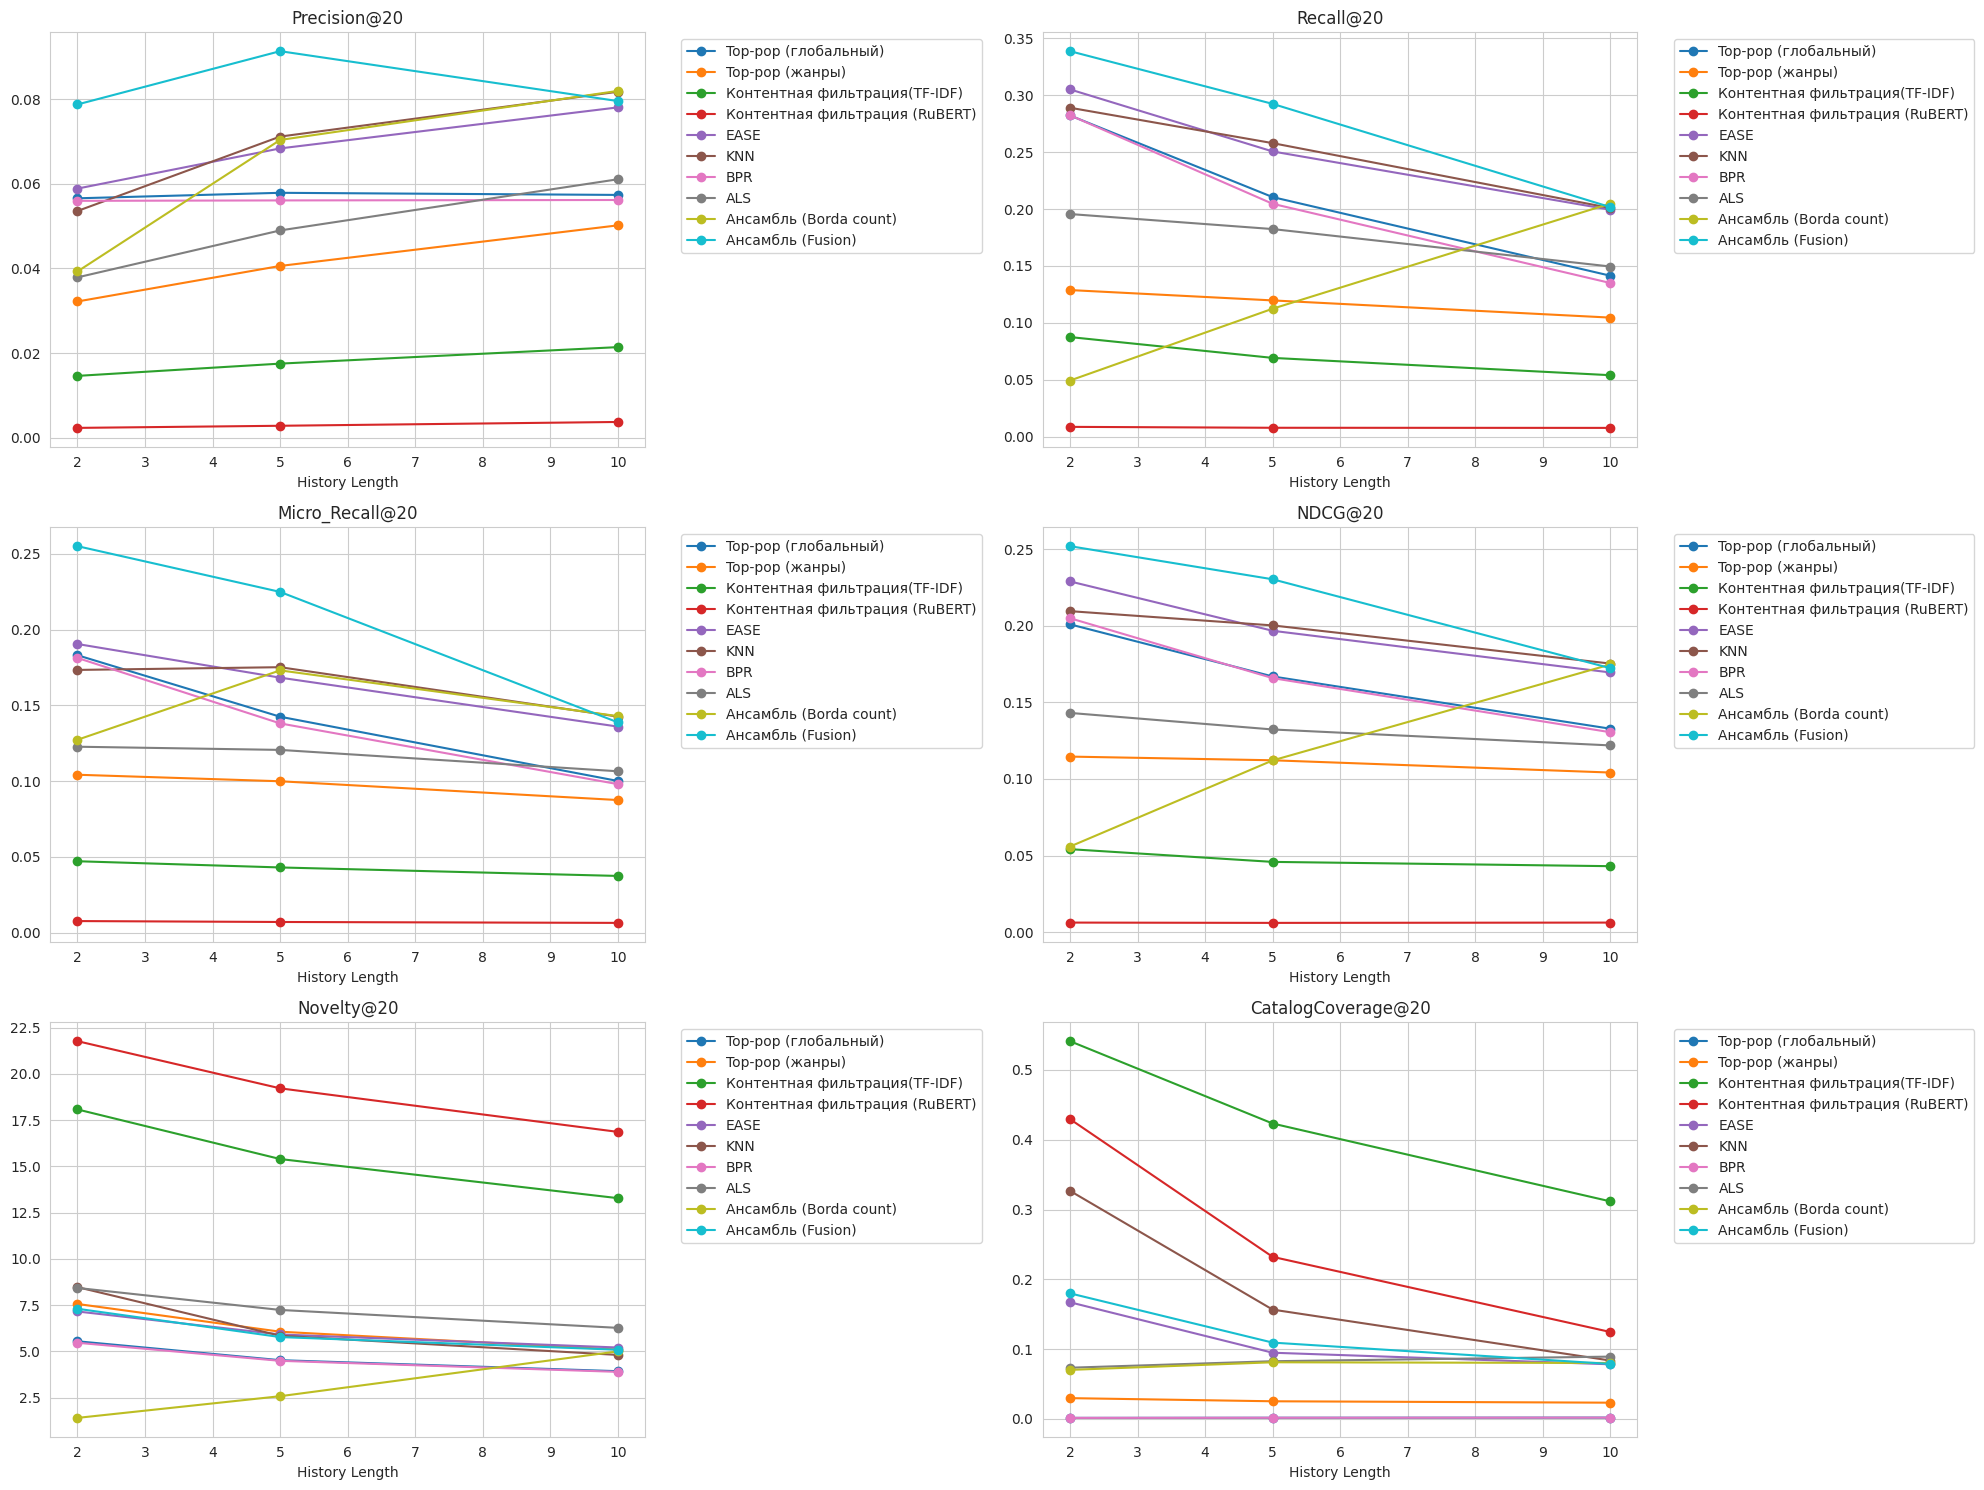

In [ ]:
sns.set_style('whitegrid')
metrics = ['Precision@20', 'Recall@20', 'Micro_Recall@20', 'NDCG@20', 'Novelty@20', 'CatalogCoverage@20']

fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    for model in cold_results_df['Model'].unique():
        sub = cold_results_df[cold_results_df['Model'] == model]
        ax.errorbar(sub['HistoryLength'], sub[metric], label=model, marker='o',
                    capsize=3)
    ax.set_title(metric)
    ax.set_xlabel('History Length')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Таким образом, ансамблевый метод с `Fusion` лучше всего использовать при ограниченной длине пользовательской истории, поскольку в таких случаях ансамбль превосходит одиночные модели значительно; при длинных историях прирост ансамбля по сравнению с `EASE` или `Item-KNN` уже не является статистически значимым - в таких случаях логичнее использовать `EASE` или `Item-KNN`, т.к. у них примерно такая же точность, но меньший вес и вычислительная сложность.

In [3]:
import json

path = "RecSys_implementation.ipynb"

with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)

print("ДО чистки, есть ли metadata.widgets:", "widgets" in nb.get("metadata", {}))
if "widgets" in nb.get("metadata", {}):
    print("Содержимое:", nb["metadata"]["widgets"])

# принудительно удаляем
nb["metadata"].pop("widgets", None)

with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1, ensure_ascii=False)

# читаем тот же файл заново, чтобы убедиться
with open(path, "r", encoding="utf-8") as f:
    nb_check = json.load(f)

print("ПОСЛЕ чистки, есть ли metadata.widgets:", "widgets" in nb_check.get("metadata", {}))

ДО чистки, есть ли metadata.widgets: False
ПОСЛЕ чистки, есть ли metadata.widgets: False
